# Setup

**Data**

[OSD-932](https://osdr.nasa.gov/bio/repo/data/studies/OSD-932): Non-Myeloid Hippocampus

---

**Processing Raw Files**

See `create_preprocessed_927_928_929_930_931_932.ipynb`:

- Retrieves fastqz and metadata (e.g., `OSD-932_metadata_OSD-927-ISA.zip`) files from OSDR and stores them in whatever directory you specify in the `superdirec` variable. **Be sure to use this same `superdirec` specification in the code cell below this markdown cell.**
- Downloads this [reference genome](), processes it for `CellRanger`, and stores it in a subdirectory of whatever directory you specify in the `superdirec` variable.
- Creates `CellRanger` Bash syntax to preprocess files (copy-pasted into `scripts_cellranger/run_cellranger_929.sh`).

---

**Annotation Guide Files**

Retrieve "GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv" from [this GitHub link](https://github.com/nasa/GeneLab_Data_Processing/blob/master/scRNAseq/10X_Chromium_3prime_Data/GeneLab_CellType_GeneMarkers/GL-DPPD-7111_GeneMarker_Files/GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv) and save it in the same directory as this notebook. The GitHub path is `nasa/GeneLab_Data_Processing/scRNAseq/10X_Chromium_3prime_Data/GeneLab_CellType_GeneMarkers/GL-DPPD-7111_GeneMarker_Files`.

Possible Map My Cells region keys = ["RHP", "RSP", "ACA", "PL-ILA-ORB", "AUD-TEa-PERI-ECT", "SS-GU-VISC", "MO-FRP", "PAL", "sAMY", "CTXsp", "HY", "STRv", "OLF", "LSX", "AI", "STRd", "VIS-PTLp", "VIS", "TH", "MOp", "ENT", "HIP", "P", "MB", "MY", "CB", "AUD", "SSp", "TEa-PERI-ECT"]

---

**Use Conda**

While in the folder containing this notebook:
`conda env create -f rapidsc.yml`



Navigate back to where you want to clone the `scflow` repository (I recommend home)
`cd`

Clone `scflow` from GitHub.
`git clone git@github.com:easlinger/scflow.git`

Navigate to the folder where `scflow` is:
`pip install .`

`pip install senepy`

---

**For NVIDIA Drivers (Linux)**

```
sudo apt update
sudo apt install -y build-essential dkms

sudo apt install -y wget
wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-ubuntu2204.pin
sudo mv cuda-ubuntu2204.pin /etc/apt/preferences.d/cuda-repository-pin-600
sudo apt-key adv --fetch-keys https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/3bf863cc.pub
sudo add-apt-repository "deb https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/ /"

sudo apt update
sudo apt install -y cuda
```

---

To clear up CUDA memory:

```
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
```

## Imports & Display

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import re
import logging
import json
from warnings import warn
try:
    import torch
    torch.set_float32_matmul_precision("medium")
except Exception:
    pass

# try:
#     import rapids_singlecell as rsc
# except Exception:
#     rsc = None

import ipynbname
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scipy.sparse as sp
import pandas as pd
import numpy as np
import scflow

for pkg in ["torch", "anndata", "scanpy",
                "pandas", "numpy", "scipy", "scflow"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

pd.set_option("display.max_rows", 500)  # or None for unlimited rows
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


class CategoricalFilter(logging.Filter):
    def filter(self, record):
        return "storing" not in record.getMessage() or \
               "as categorical" not in record.getMessage()


logger = logging.getLogger("anndata")
logger.addFilter(CategoricalFilter())

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/jaxopt/__init__.py:59: DeprecationWarning: JAXopt is no longer maintained. See https://docs.jax.dev/en/latest/ for alternatives.
  warnings.warn(
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/marshmallow/__init__.py:17: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  __version_info__ = tuple(LooseVersion(__version__).version)
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/marshmallow/fields.py:198: RemovedInMarshmallow4Warning: Passing field metadata as a keyword arg is deprecated. Use the explicit `metadata=...` argument instead.
  warnings.warn(
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_nam

torch: 2.8.0
anndata: 0.12.1
scanpy: 1.11.4
pandas: 2.2.3
numpy: 2.2.6
scipy: 1.15.3
scflow: 0.0.0


## Set Options (ACTIVELY SET THESE!)

**Note: The new h5ad data file will write to "data" sub-directory of where this notebook is.** 

(See line `direcs = [os.path.join(superdirec, i) for i in batches]`.)

--- 
**Examples of other ways of specifying options:**

`file_md` if from OSDR:

* `file_md = {i: f"{i}_metadata_{i}-ISA/s_{i}.txt" for i in batches}`

`file_timings`: Specify time of dissection for certain OSD datasets

* `file_timings = "RRRM-2 Dissection Timing_ISS-T[29][91].xlsx"`

`subcluster_biggest`

* `subcluster_biggest = 3  # sub-cluster biggest 3 clusters`
* `subcluster_biggest = 1  # sub-cluster biggest cluster`
* `subcluster_biggest = False  # no sub-clustering`

`kws_cluster`

* `kws_cluster = dict(n_comps=50)  # cluster individual samples`
* `kws_cluster = None  # do not cluster individual samples`

`vars_regress_out`: To regress variables out of concatenated object

* `vars_regress_out = ["Time", "pct_counts_mt", "total_counts"]`

`covariates_categorical`

* `covariates_categorical = ["Comment[Euthanasia Date]"]`
* `covariates_continuous = ["Time"]`

For certain OSD datasets, age at beginning or region + cell type (material): 

* `col_age = "Factor Value[Age]"`
* `col_material = "Characteristics[Material Type]"`

`map_my_cells_region_keys`

* Possible Map My Cells region keys = ["RHP", "RSP", "ACA", "PL-ILA-ORB", "AUD-TEa-PERI-ECT", "SS-GU-VISC", "MO-FRP", "PAL", "sAMY", "CTXsp", "HY", "STRv", "OLF", "LSX", "AI", "STRd", "VIS-PTLp", "VIS", "TH", "MOp", "ENT", "HIP", "P", "MB", "MY", "CB", "AUD", "SSp", "TEa-PERI-ECT"]

---

In [20]:
# Batch Information
batches = ["OSD-932"]

# Annotation Required, Prohibited, & Unconsidered Cell Types
req_cts = ["Neuron", "Endothelial"]
unannot_cts = ["M1 Macrophage"]
prohib_cts = ["Excitatory-Inhibitory"]

# Set Data (& Meta-Data `file_md`) Sources & Species
superdirec = "/home/easlinger/data"  # directory with original data
species = "Mouse"
file_timings = None
file_md = {i: f"{superdirec}/{i}_metadata_{i}-ISA/s_{i}.txt" for i in batches}
file_md_assay = {i: str(f"{superdirec}/{i}_metadata_{i}-ISA/a_{i}_"
                        "transcription-profiling_single-cell-rna-sequencing_"
                        "Illumina.txt") for i in batches}

# Process
n_processors = os.cpu_count() - 1  # how many processors to use
overwrite = True  # allow overwrite of files?
ondisk = False

# If You Want Results Emailed
email = None
# email = "elizabeth.aslinger@aya.yale.edu" # set email to None to skip

# Set Source Data Directory & Output Options
file_concat = os.path.join("data", f"{'_'.join(batches)}_concatenated.h5ad")
file_new = os.path.join("data", f"{'_'.join(batches)}_integrated.h5ad")

# Set Sample & Batch IDs, Plus Other Potential Sources of Batch Effects
col_group = "Group"  # age &/or space flight
col_batch = "batch" if len(batches) > 1 else col_group
col_age = "Factor Value[Age]"
# col_age = "Factor Value[Age]"
col_condition = "Factor Value[Spaceflight]"
col_sample = "Source Name"  # sample column to use eventually
col_sample_original = "Sample Name"  # original sample column name in metadata
col_material = "Characteristics[Material Type]"  # split cell kind & region
col_subject = None  # in case of replicates of subjects across batches

# ^ ...will split words in this column => columns "CellSort" & "Brain_Region"
covariates_categorical = ["CellSort"]  # or None
covariates_continuous = None

# Preprocessing/Clustering
subcluster_biggest = False  # no sub-clustering
# kws_cluster = dict(n_comps=50)  # cluster individual samples
kws_cluster = None
vars_regress_out = None
remove_mt_genes = False

# Make Pre-Defined Marker Dictionary
file_mks_a_priori = "GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers_new.csv"
cts_superhierarchical = {
    "Neuron": ["Excitatory", "Inhibitory", "Glutamatergic", "GABAergic",
               "Dopaminergic", "Serotonergic", "Cholinergic"],
}  # e.g., if classified as Neuron + other, just keep more specific type(s)
rename_marker_based_annotation = {
    "Excitatory | Inhibitory": "Excitatory-Inhibitory",
    "Inhibitory | Inhibitory": "Excitatory-Inhibitory",
    "Oligodendrocyte | Microglial | OPC": "Oligodendrocyte"
}  # e.g., allow for renaming as Exitatory-Inhibitory if no consensus on which

# Set Annotation Sources
map_my_cells_source = "WMB-10X" if species == "Mouse" else "WHB-10X" if (
    species == "Human") else None  # Map My Cells atlas source
# map_my_cells_region_keys = None
map_my_cells_region_keys = [
    "RSP", "ACA", "PL-ILA-ORB", "AUD-TEa-PERI-ECT", "SS-GU-VISC", "MO-FRP",
    "AI", "VIS-PTLp", "VIS", "MOp", "AUD", "SSp",
    "TEa-PERI-ECT"]  # regional subset for Map My Cells
map_my_cells_cell_keys = ["Isocortex"]  # pattern match: feature name column
source_patterns = ["Brain", "Cortical", "cortex"]  # for ToppGene
model_celltypist = "Mouse_Whole_Brain.pkl"

## Input Checks & Derived Settings

You might want to look over this code to make sure derived variables are what you want them to be, but it should work out of the box in most circumstances.

If you specified `file_timings`, you probably want to check if the format works with this code.

In [41]:
# Current File & Data Directories
direcs = [os.path.join(superdirec, i) for i in batches]
cur_file = os.path.join(os.path.abspath(""), f"{ipynbname.name()}.ipynb")
html_out = os.path.splitext(cur_file)[0] + ".html"

# A Priori Marker Dictionary
mks_a_priori = pd.read_csv(file_mks_a_priori, index_col=0).iloc[:, 0]
mks_a_priori = dict(mks_a_priori.groupby(mks_a_priori.index.names[0]).apply(
    set)) if "," not in str(mks_a_priori.iloc[0]) else dict(
        mks_a_priori.apply(lambda x: set(x.split(","))))

# Marker Dictionaries with Super-Hierarchical Merging & Collapsing
markers_predefined = {**mks_a_priori}
if cts_superhierarchical is not None:
    for i in cts_superhierarchical:
        for k in [u for u in cts_superhierarchical[
                i] if u in markers_predefined]:
            markers_predefined[k] = markers_predefined[k].union(
                markers_predefined[i])
    _ = [markers_predefined.pop(i, None) for i in cts_superhierarchical]
mks_collapsed = {**mks_a_priori}
# if "Neuron" in mks_collapsed and "Excitatory" in mks_collapsed and \
#         "Inhibitory" in mks_collapsed:
#     mks_collapsed["Neuron"] = mks_collapsed["Neuron"].union(mks_collapsed[
#         "Excitatory"]).union(mks_collapsed["Inhibitory"])
# _ = mks_collapsed.pop("Excitatory", None)
# _ = mks_collapsed.pop("Inhibitory", None)
# if "Oligodendrocyte" in mks_collapsed and "OPC" in mks_collapsed:
#     mks_collapsed["Oligodendrocyte"] = mks_collapsed[
#         "Oligodendrocyte"].union(mks_collapsed["OPC"])
# _ = mks_collapsed.pop("OPC", None)

# Check Inputs
if model_celltypist == "Mouse_Whole_Brain.pkl" and species != "Mouse":
    raise ValueError("Manually set `model_celltypist` for non-mouse!")
if species != "Mouse":
    if "Mmus" in file_mks_a_priori:
        raise ValueError(
            f"`file_mks_a_priori` ({file_mks_a_priori}) not for species. "
            f"Set new file appropriate for species {species}.")

# Get Metadata
if file_md is not None:
    metadata = [pd.read_csv(
        os.path.join(superdirec, file_md[i]),
        sep=None, engine="python").set_index(col_sample_original).join(
            pd.read_csv(os.path.join(superdirec, file_md_assay[i]),
                        sep=None, engine="python").set_index(
                            col_sample_original)[["Raw Data File"]])
                for i in batches]  # list of metadata for each batch
    for u in np.arange(len(metadata)):  # combined age & condition variable
        metadata[u] = metadata[u].join(metadata[u].apply(
            lambda x: x[col_condition] + str(
                " | " + str(x[col_age]) + " Weeks" if (
                    col_age in metadata[u].columns and len(
                        metadata[u][col_age].unique()) > 1) else ""),
            axis=1).to_frame(col_group))  # add space flight (x age if have)
        if col_material is not None:
            metadata[u] = metadata[u].join(metadata[u][col_material].apply(
                lambda x: pd.Series(x.split(" "), index=[
                    "CellSort", "Brain_Region"])))  # region & myeloid vs. not
else:
    metadata = None

## Load Individual Sample Data

```
sample_cr_align = pd.Series(files).rename_axis("Sample").apply(
    lambda x: os.path.basename(x.split("/outs")[0])).to_frame(
        "SRX").reset_index().set_index("SRX")
md_chk = metadata_combined["Raw Data File"].apply(
    lambda x: x.split(",")[0]).apply(
        lambda x: x.split("_R1")[0].split("Seq_")[1]).to_frame(
            "SRX").reset_index().set_index("SRX")
md_chk = md_chk.join(sample_cr_align).set_index(
    col_batch, append=True).reorder_levels([1, 0]).groupby(
        col_batch).apply(lambda x: x.sort_index()).reset_index(0, drop=True)
md_chk
```

In [5]:
%%time

# Create a Subdirectory of Working Directory for Data Outputs
os.makedirs("data", exist_ok=True)

# Detect If Subject Replicates across Batches
samples = pd.DataFrame({os.path.basename(d): [metadata[u][col_sample].loc[
    metadata[u].index[metadata[u]["Raw Data File"].apply(
        lambda q: q.split("_")[2]) == x][0]] for x in [
            i for i in os.listdir(d) if os.path.isdir(os.path.join(
                d, i))]] for u, d in enumerate(direcs)}).stack()
dups = bool(samples.reset_index(drop=True).duplicated().any())

# Load Data
adatas, files = {}, {}
for u, d in enumerate(direcs):  # iterate over directories (batches)
    subdirs = [i for i in os.listdir(d) if os.path.isdir(os.path.join(d, i))]
    for x in subdirs:  # iterate sample subdirectories within batch directory
        i_x = metadata[u].index[metadata[u]["Raw Data File"].apply(
            lambda q: q.split("_")[2]) == x]  # match file to sample
        if len(i_x) > 1:
            raise ValueError(f"More than one index found for {x}: {i_x}")
        sample = metadata[u][col_sample].loc[i_x[0]]
        subject = str(sample) if dups is True else None  # subject != sample?
        if dups is True:
            sample = sample + "_" + batches[u]
        files[sample] = os.path.join(d, x, "outs/filtered_feature_bc_matrix")
        adatas[sample] = sc.read_10x_mtx(files[sample])  # read anndata

        # Metadata to `.obs`
        if col_batch is not None:  # if a batch column specified
            adatas[sample].obs.loc[:, col_batch] = batches[u]  # batch => .obs
        if subject is not None:
            adatas[sample].obs.loc[:, col_subject] = subject
        adatas[sample].obs.loc[:, col_sample] = sample  # sample ID => .obs
        if metadata is not None:  # sample-specific metadata if available
            samp_metadata = metadata[u].loc[i_x[0]]  # sample metadata
            for v in samp_metadata.index.values:  # metadata => .obs columns
                adatas[sample].obs.loc[:, v] = samp_metadata.loc[v]
        adatas[sample].obs.loc[:, f"n_cells_original_{col_sample}"] = adatas[
            sample].obs.shape[0]  # original number of cells
        print(adatas[sample])

print(files)
metadata_combined = None if metadata is None else pd.concat(
    metadata, keys=batches, names=[col_batch])
metadata_combined

AnnData object with n_obs × n_vars = 1917 × 78239
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 'Parameter Value[Feeding Schedule]', 'Parameter Value[duration]', 'Unit.1', 'Term Source REF.7', 'Term Accession Number.7', 'Parameter Value[light cycle]', 'Parameter Value[habitat]', 'Parameter Value[Enrichment material]', 'Protocol REF.1', 'Parameter Value[Euthanasia Location]', 'Parameter Value[Dissection

Source Name Characteristics[Organism] Term Source REF                              Term Accession Number Characteristics[Strain] Term Source REF.1 Term Accession Number.1  \
Group   Sample Name                                                                                                                                                                              
OSD-932 GSM8947917    HC_LAR_09              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947918    HC_LAR_19              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947919    HC_LAR_10              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947920    HC_LAR_20              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947921    FL_LAR_09              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947922    FL_LAR_19              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947923    FL_LAR_10              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   
        GSM8947924    FL_LAR_20              Mus musculus       NCBITAXON  http://purl.bioontology.org/ontology/NCBITAXON...            BALB/cAnNTac               OSD  https://osdr.nasa.gov/   

                    Characteristics[Genotype] Term Source REF.2                     Term Accession Number.2 Characteristics[Sex] Term Source REF.3                            Term Accession Number.3  \
Group   Sample Name                                                                                                                                                                                     
OSD-932 GSM8947917                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947918                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947919                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947920                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947921                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947922                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947923                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   
        GSM8947924                  Wild Type              NCIT  http://purl.obolibrary.org/obo/NCIT_C62195               Female              MESH  http://purl.bioontology.org/ontology/MESH/D005260   

                    Factor Value[Spaceflight] Term Source REF.4     

# QC

## Perform Sample-Specific QC

Mouse pairing weird technical variation?

```
tmp2 = samples.rename_axis(["", col_batch]).to_frame(
    "subject").reset_index(0, drop=True).reset_index().set_index("subject")
tmp2 = tmp2.reset_index().assign(**{"Source Name": tmp2.reset_index().apply(
    lambda x: x["subject"] + "_" + x[col_batch], axis=1)})
tmp2.set_index("Source Name", inplace=True)
tmp = descriptives.stack().to_frame("V").join(tmp2).set_index([
    "batch", "subject"], append=True).reset_index(
        "Source Name", drop=True).loc[:, "pct_counts_mt", :]
tmp = tmp.V.unstack("Metric")[["50%"]]
tmp = tmp.join(tmp.groupby("subject").apply(
    lambda x: x.name.split("_")[0]).to_frame("Condition"))
tmp = tmp.join(tmp.groupby("subject").apply(lambda x: "_".join(x.name.split(
    "_")[1:])).to_frame("s")).set_index(["Condition", "s"], append=True)
tmp["50%"].reset_index([col_condition, "subject"], drop=True).reorder_levels(
    [0, 2, 1]).sort_index().unstack("s").unstack(col_batch)
```

Variable                                     n_cells_by_counts  n_genes_by_counts  pct_counts_mt  total_counts
Source Name Group                    Metric                                                                   
FL_LAR_09   Space Flight | 3 Weeks   count             78239.0              422.0          422.0         422.0
                                     mean                  8.0             1392.0           21.0        5432.0
                                     std                  21.0             1862.0           16.0        9876.0
                                     min                   0.0               21.0            1.0         500.0
                                     2.5%                  0.0              216.0            1.0         521.0
                                     10%                   0.0              251.0            3.0         567.0
                                     25%                   0.0              323.0            5.0         682.0
                                     50%                   0.0              455.0           19.0        1062.0
                                     75%                   2.0             1275.0           31.0        4272.0
                                     85%                  11.0             3821.0           39.0       13106.0
                                     90%                  24.0             4738.0           44.0       20228.0
                                     97.5%                75.0             6309.0           54.0       33882.0
                                     max                 422.0            10153.0           80.0       86850.0
FL_LAR_10   Space Flight | 3 Weeks   count             78239.0              758.0          758.0         758.0
                                     mean                 18.0             1853.0           13.0        7281.0
                                     std                  48.0             2058.0           12.0       10876.0
                                     min                   0.0               25.0            0.0         502.0
                                     2.5%                  0.0              180.0            1.0         520.0
                                     10%                   0.0              253.0            2.0         592.0
                                     25%                   0.0              351.0            3.0         775.0
                                     50%                   0.0              674.0            9.0        1633.0
                                     75%                   7.0             3348.0           21.0       10363.0
                                     85%                  27.0             4559.0           26.0       18093.0
                                     90%                  59.0             5001.0           31.0       21961.0
                                     97.5%               175.0             6828.0           46.0       37112.0
                                     max                 758.0             9694.0           73.0       83068.0
FL_LAR_19   Space Flight | 8 Weeks   count             78239.0              381.0          381.0         381.0
                                     mean                  6.0             1194.0           23.0        4173.0
                                     std                  17.0             1575.0           17.0        7125.0
                                     min                   0.0              114.0            0.0         502.0
                                     2.5%                  0.0              198.0            2.0         516.0
                                     10%                   0.0              242.0            3.0         553.0
                                     25%                   0.0              301.0            7.0         671.0
                                     50%                   0.0              433.0           23.0        1032.0
    

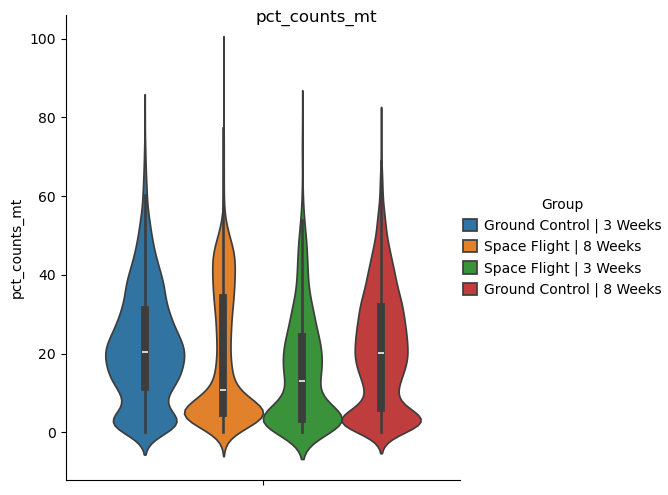

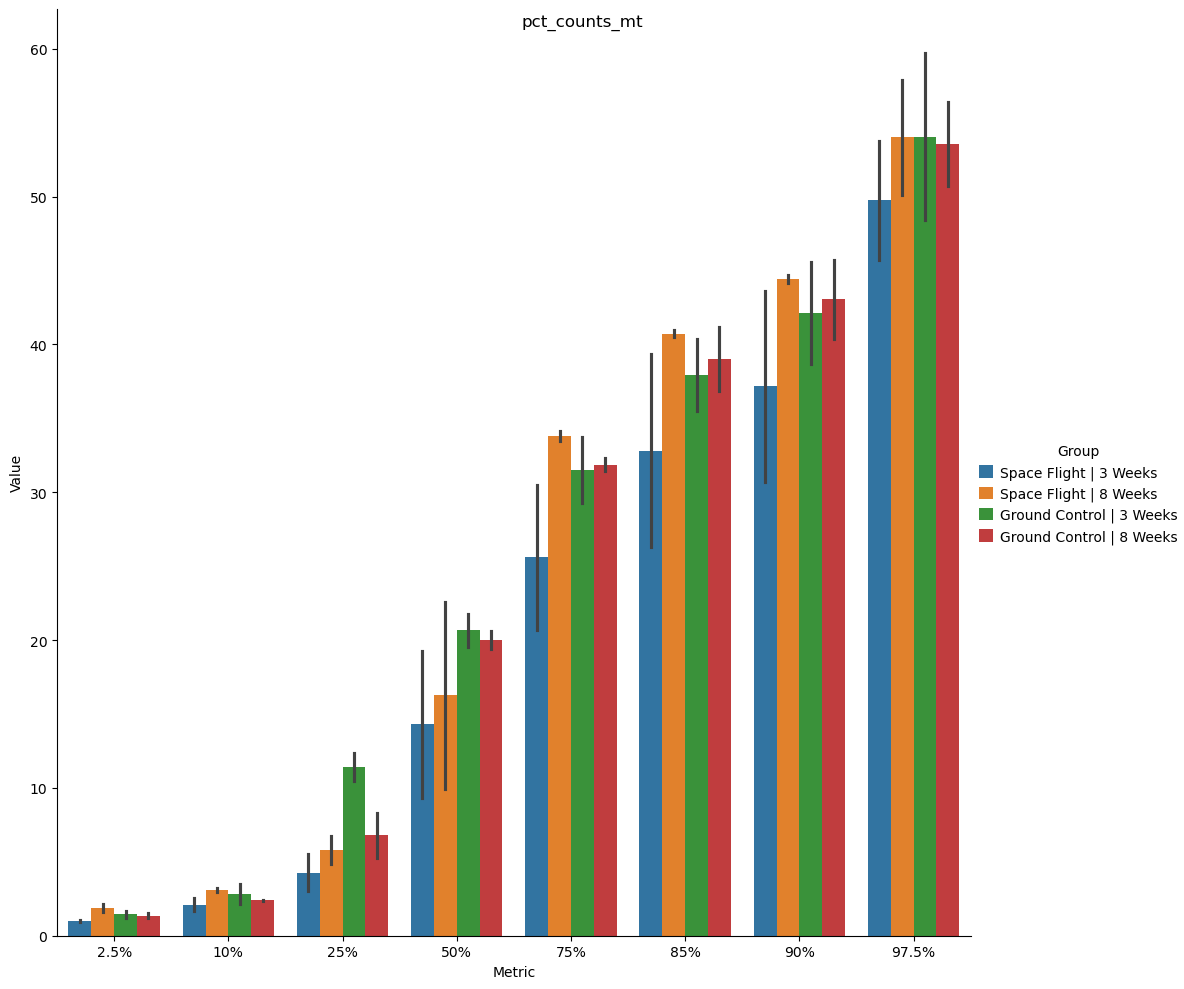

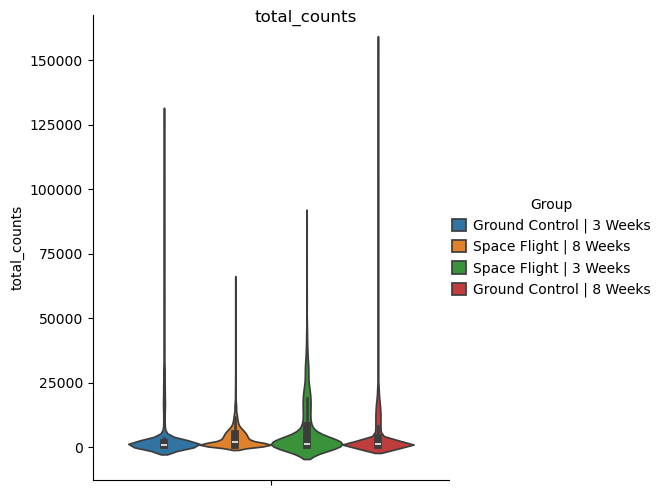

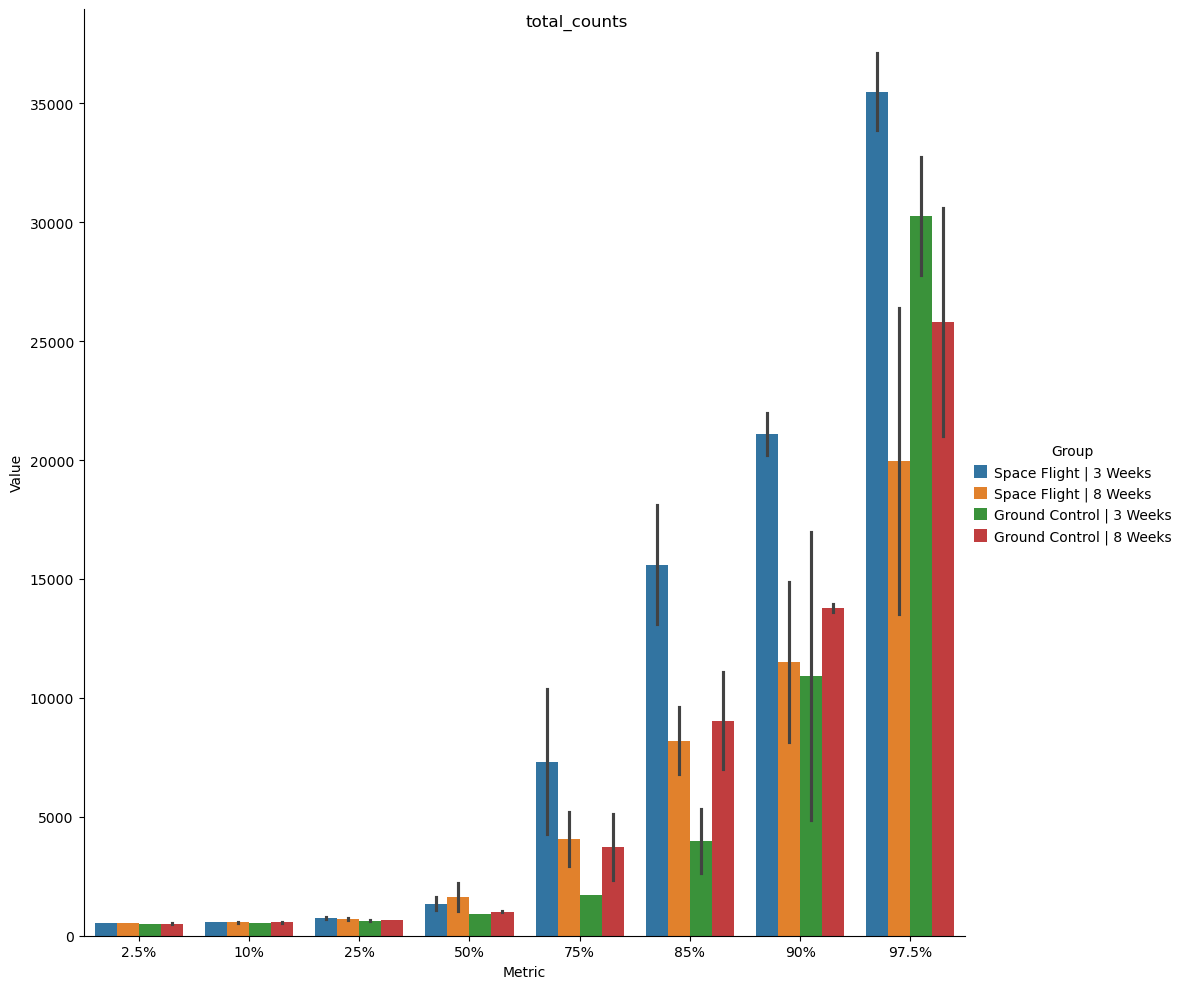

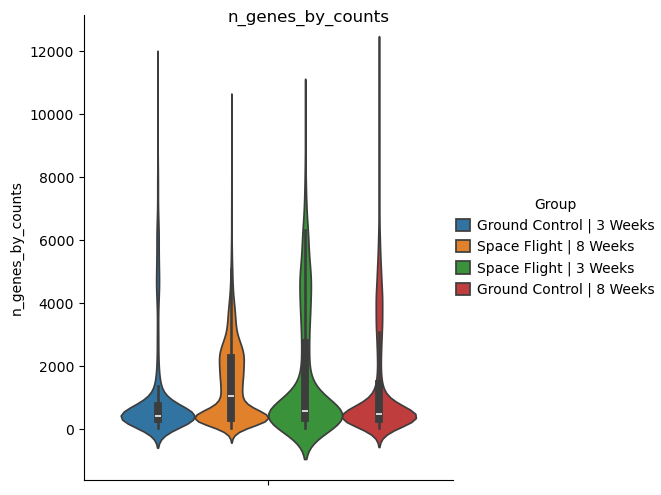

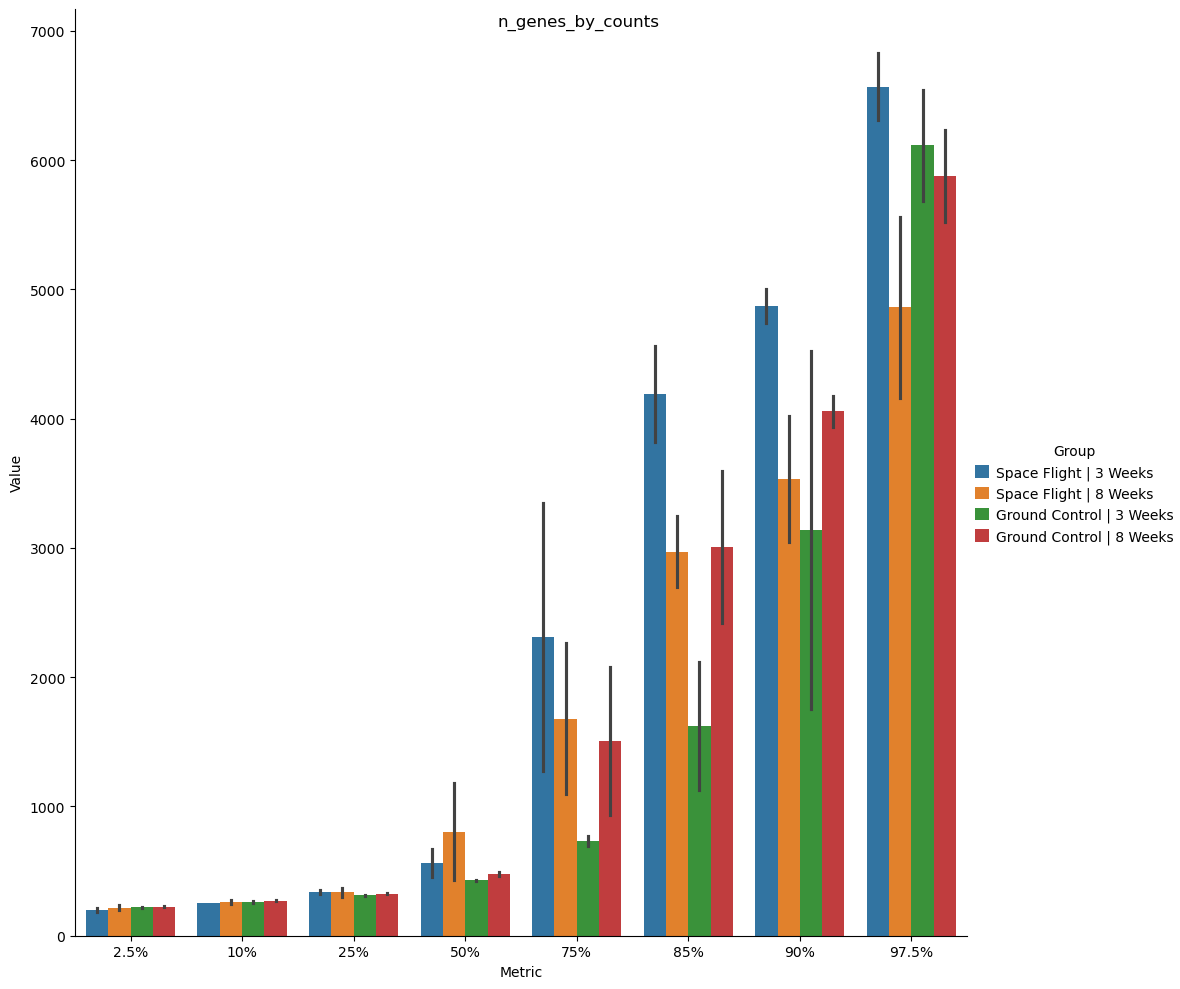

In [6]:
%matplotlib inline

plot_qc = False  # change to True to get sample-level QC plots (a bit slow)
qcs, n_cells_by_counts, descriptives, figs = scflow.pp.perform_qc_multi(
    adatas, col_batch=col_batch, col_sample=col_sample, plot=plot_qc,
    percentiles=[0.025, 0.10, 0.25, 0.50, 0.75, 0.85, 0.90, 0.975],
    figsize=(10, 10))  # perform QC on individual samples
for x in qcs:  # iterate QC metrics % plot percentiles by group
    fig = sns.catplot(qcs, y=x, hue=col_batch, kind="violin")
    fig.fig.suptitle(x)
    fig = sns.catplot(descriptives.loc[:, :, x][[
        i for i in descriptives if ("%" in i)]].stack().to_frame("Value"),
                      x="Metric", y="Value", kind="bar",
                      hue=col_batch, height=10)
    fig.fig.suptitle(x)
# qcs["total_counts"].describe()
# descriptives.stack().unstack("Variable")["pct_counts_mt"].unstack(-1)[
#     "75%"].sort_values()
# descriptives.stack().unstack("Variable")["total_counts"].unstack(-1)[
#     "75%"].sort_values()
# descriptives.stack().unstack("Variable")["n_genes_by_counts"].unstack(-1)[
#     "90%"].sort_values()
# descriptives.stack().unstack("Variable")["n_cells_by_counts"].unstack(-1)[
#     "75%"].sort_values()
descriptives.stack().unstack("Variable").round()

## Auto-Detect Filtering Thresholds

Use 2.5th and/& 97.5th percentile (sample-specific) as minimum genes per cell and minimum and maximum total counts (subject to specified absolute minima). Use 97.5th percentile as upper bound for percent mitochondrial count. 

Use an absolute minimum cells per gene.

Also include arguments to run a PCA on individual samples before integrating.

In [7]:
# Options
bounds = descriptives[["2.5%", "97.5%"]].apply(lambda x: list(
    x), axis=1).unstack("Variable")  # list top/bottom 5% (~sample, variable)
abs_min_cells = 1  # regardless of %ile, minimum cells to retain gene
abs_min_genes = 200  # regardless of %ile, minimum genes to retain cell
abs_min_count = 500  # regardless of %ile, minimum counts to retain cell
abs_max_mt = 30  # regardless of %ile, absolute maximum mitochonrial content
n_top_genes = 2000  # number of top genes to count as HVGs

# Set Thresholds
kws_pp = {}
for x in adatas:
    b_x = bounds.loc[x]
    b_counts =  b_x["total_counts"] if isinstance(b_x[
            "total_counts"], list) else b_x["total_counts"].iloc[0]
    b_counts = [max(b_counts[0], abs_min_count), b_counts[1]]
    kws_pp[x] = {
        "min_max_genes": [max((b_x["n_genes_by_counts"] if isinstance(
            b_x["n_genes_by_counts"], list) else b_x[
                "n_genes_by_counts"].iloc[0])[0], abs_min_genes), None],
        "min_max_cells": [abs_min_cells, None],
        # "min_max_cells": [max((b_x["n_cells_by_counts"] if isinstance(
        #     b_x["n_genes_by_counts"], list) else b_x[
        #         "n_genes_by_counts"].iloc[0])[0], abs_min_cells), None],
        # "max_mt": min(abs_max_mt, (b_x["pct_counts_mt"] if isinstance(b_x[
        #     "pct_counts_mt"], list) else b_x["pct_counts_mt"].iloc[0])[1]),
        "max_mt": abs_max_mt,
        "min_max_counts": b_counts,
        # "vars_regress_out": ["total_counts"],
        "target_sum": 1e4,
        "zero_center": True, "max_value": 10,  # scaling
        "n_top_genes": n_top_genes,
        "doublet_detection": "drop"
    }
print("\n".join([f"{s}: {kws_pp[s]}" for s in kws_pp]))
pd.DataFrame(kws_pp).T

HC_LAR_09: {'min_max_genes': [218.0, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [509.9, 32748.099999999995], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
HC_LAR_10: {'min_max_genes': [226.0, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [511.0, 27801.5], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
FL_LAR_19: {'min_max_genes': [200, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [516.5, 26408.5], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
FL_LAR_09: {'min_max_genes': [215.725, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [521.05, 33882.499999999956], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
HC_LAR_19: {'min_max_genes': [230.72500000000

,min_max_genes,min_max_cells,max_mt,min_max_counts,target_sum,zero_center,max_value,n_top_genes,doublet_detection
HC_LAR_09,"[218.0, None]","[1, None]",30,"[509.9, 32748.099999999995]",10000.0,True,10,2000,drop
HC_LAR_10,"[226.0, None]","[1, None]",30,"[511.0, 27801.5]",10000.0,True,10,2000,drop
FL_LAR_19,"[200, None]","[1, None]",30,"[516.5, 26408.5]",10000.0,True,10,2000,drop
FL_LAR_09,"[215.725, None]","[1, None]",30,"[521.05, 33882.499999999956]",10000.0,True,10,2000,drop
HC_LAR_19,"[230.72500000000002, None]","[1, None]",30,"[513.0, 21025.325000000008]",10000.0,True,10,2000,drop
FL_LAR_10,"[200, None]","[1, None]",30,"[520.0, 37112.149999999994]",10000.0,True,10,2000,drop
HC_LAR_20,"[219.0, None]","[1, None]",30,"[514.0, 30613.300000000003]",10000.0,True,10,2000,drop
FL_LAR_20,"[234.0, None]","[1, None]",30,"[519.0, 13542.399999999998]",10000.0,True,10,2000,drop


# Preprocess Individual

## Filter & Normalize

In [8]:
# Preprocess
if overwrite is False:
    raise ValueError("Must be able to overwrite to use on-disk option")
files_individual = dict(zip(files.keys(), [os.path.join(
    "data", f"{x}_processed.h5ad") for x in files]))  # new individual files
var_names = []  # to store genes not filtered out for each sample
for x in files:  # iterate sample files
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}")
    adatas[x].obs.loc[:, f"kws_pp_{col_sample}"] = str(kws_pp[x])  # store kws
    adatas[x] = scflow.pp.preprocess(adatas[x], **kws_pp[x], plot_qc=False)
    var_names += [set(adatas[x].var_names)]  # track what genes still present

# Decide Join Method
shared_genes = set.intersection(*var_names)  # genes in all after filtering
all_genes = set.union(*var_names)  # genes in any post-filter sample
print(f"\n\n{len(shared_genes)} genes present in all samples post-filtering ("
      f"out of {len(all_genes)} total genes in any post-filter sample)\n\n")
# join_method = "inner" if len(shared_genes) / len(all_genes) >= 0.5 else \
#     "outer"  # outer join if <1/2 of genes shared across all samples
join_method = "inner"

# Number of Cells
n_cells = pd.DataFrame({x: pd.Series({
    "n_cells_original": adatas[x].obs[f"n_cells_original_{col_sample}"].iloc[
        0], "n_cells": adatas[x].obs.shape[0]}) for x in adatas}).T
n_cells = n_cells.assign(percent_cells_retained=100 * round(n_cells[
    "n_cells"] / n_cells["n_cells_original"], 2))
print(f"\n\n\n{'=' * 80}\n# Cells Post-Processing\n{'=' * 80}\n\n")
n_cells



HC_LAR_09
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 1917 × 78239
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 'Parameter Value[Feeding Schedule]', 'Parameter Value[duration]', 'Unit.1', 'Term Source REF.7', 'Term Accession Number.7', 'Parameter Value[light cycle]', 'Parameter Value[habitat]', 'Parameter Value[Enrichment material]', 'Protocol REF.1', 'Parameter Value[Eutha

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


Automatically set threshold at doublet score = 0.29
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 2.5%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 6.0%
	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


HC_LAR_10
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 1691 × 78239
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


Automatically set threshold at doublet score = 0.26
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 5.6%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 6.6%
	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


FL_LAR_19
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 381 × 78239
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', '

...

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


Automatically set threshold at doublet score = 0.27
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 5.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 1.7%
	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


FL_LAR_20
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 3897 × 78239
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


Automatically set threshold at doublet score = 0.35
Detected doublet rate = 0.7%
Estimated detectable doublet fraction = 19.3%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 3.6%
	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


19952 genes present in all samples post-filtering (out of 49716 total genes in any post-filter sample)





# Cells Post-Processing




,n_cells_original,n_cells,percent_cells_retained
HC_LAR_09,1917,1347,70.0
HC_LAR_10,1691,1078,64.0
FL_LAR_19,381,243,64.0
FL_LAR_09,422,287,68.0
HC_LAR_19,3830,2538,66.0
FL_LAR_10,758,611,81.0
HC_LAR_20,1723,1120,65.0
FL_LAR_20,3897,2600,67.0


## Test Preprocessing

Unit tests

In [9]:
for p, ann in zip([kws_pp[x] for x in kws_pp], [adatas[x] for x in adatas]):
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n")
    if join_method == "inner":
        assert all(ann.var["n_cells_by_counts"] >= p["min_max_cells"][0])
        assert all(ann.var["n_cells_by_counts"] <= p[
            x]["min_max_cells"][1]) if kws_pp[x]["min_max_cells"][1] else True
    assert all(ann.obs["n_genes_by_counts"] >= p["min_max_genes"][0])
    assert all(ann.obs["n_genes_by_counts"] <= p[
        "min_max_genes"][1]) if p["min_max_genes"][1] else True
    assert all(ann.obs["pct_counts_mt"] <= p["max_mt"])
    assert all(ann.obs["total_counts"] >= p["min_max_counts"][0])
    assert all(ann.obs["total_counts"] <= p["min_max_counts"][1]) if (
        p["min_max_counts"][1]) else True
    print(p)
    print(ann.obs[["n_genes", "pct_counts_mt", "total_counts"]
                  ].describe().loc[["min", "max"]])
    print(ann.var[["n_cells_by_counts"]].describe().loc[[
        "min", "max"]])

# Mitochondrial Genes
print(f"\n\n\n{'=' * 80}\nNumber of HVG MT Genes\n{'=' * 80}\n\n")
print([adatas[x].var.loc[[i for i in adatas[x].var_names if "mt-" in i.lower(
    )]].highly_variable.sum() for x in adatas])



FL_LAR_20

{'min_max_genes': [218.0, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [509.9, 32748.099999999995], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
     n_genes  pct_counts_mt  total_counts
min    218.0       0.000000         510.0
max   7035.0      29.989328       32741.0
     n_cells_by_counts
min                1.0
max             1912.0


FL_LAR_20

{'min_max_genes': [226.0, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [511.0, 27801.5], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
     n_genes  pct_counts_mt  total_counts
min    226.0       0.133571         511.0
max   6126.0      29.969418       27782.0
     n_cells_by_counts
min                1.0
max             1691.0


FL_LAR_20

{'min_max_genes': [200, None], 'min_max_cells': [1, None], 'max_mt': 30, 'min_max_counts': [516.5, 26408.5], 'target

# Cluster Individual

Iterate different clustering parameters to ensure extraction of common cell types

Make sample-specific alterations to one sample's annotation

In [10]:
# Clustering Parameter Options
if kws_cluster is None:
    for x in adatas:
        print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n{adatas[x]}\n")
        if "tocsr" in dir(adatas[x].X):
            adatas[x].X = adatas[x].X.tocsr()
        for q in adatas[x].layers:
            if sp.issparse(adatas[x].layers[q]):
                adatas[x].layers[q] = adatas[x].layers[q].tocsr()
        if ondisk is True:
            adatas[x].write_h5ad(files_individual[x])  # write individual file
    if ondisk is True:
        del adatas
        adatas = None
    raise ValueError("Not doing individual clustering because "
                     "`kws_cluster` was specified as None")
    # TODO: Find more elegant way of not running cell if kws_cluster=None

annotate = True
resn_list = [0.1, 0.2, 1.2, 0.3, 0.4, 0.5, 0.7, 1, 0.075, 0.15]
dist_list = [0.3, 0.5, 0.75, 1, 1.5]
col_cluster_individual = "annotation_by_markers_individual"
unlabeled_cat = "Heterogeneous"  # if can't find one best-fit cell label
cci_scanvi = col_cluster_individual + "_heterogeneous_collapsed"
sep = " | "  # separator for heterogeneous annotations

# Clustering
for x in files:  # iterate sample files
    valid_cts = False
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}")
    if remove_mt_genes is True:
        adatas[x] =   adatas[x][:, ~adatas[x].var_names.str.startswith((
            "MT-", "Mt-", "mt-"))]
    for r in resn_list:
        if valid_cts is True:
            break
        for t in dist_list:
            if valid_cts is True:
                break
            c_i = f"leiden_individual_res{r}dist{t}"
            cai = f"{col_cluster_individual}_res{r}dist{t}"
            kws_cl = {"resolution": r, "min_dist": t, **kws_cluster}
            adatas[x] = scflow.pp.cluster(
                adatas[x], plot=False, col_celltype=c_i, **kws_cl)
            sc.tl.rank_genes_groups(
                adatas[x], c_i, key_added=f"rank_genes_groups_{c_i}",
                n_genes=None, copy=False)  # find markers/DEGs
            if annotate is False:
                valid_cts = True
                adatas[x].obs.loc[:, "leiden_individual"] = adatas[x].obs[c_i]
                adatas[x].obs.loc[:, "kws_cluster_individual"] = str(kws_cl)
                continue
            rcts, pcts, ucts = [z[adatas[x].obs[col_batch].iloc[0]] if (
                isinstance(z, dict)) else z for z in [
                    req_cts, prohib_cts, unannot_cts]]  # batch-specific?
            if ucts is not None:
                mksci = {z: mks_collapsed[z] for z in mks_collapsed if (
                    z not in ucts)}  # remove certain 1s from annotation guide
            _, adatas[x] = scflow.pp.annotate_by_marker_overlap(
                adatas[x], mksci, col_celltype=c_i, col_celltype_new=cai,
                sep=sep, celltypes_superhierarchical=cts_superhierarchical,
                # top_n_markers=20,
                adj_pval_threshold=1e-15,
                method="overlap_count", inplace=True)  # annotate
            if rename_marker_based_annotation is not None:
                adatas[x].obs.loc[:, cai] = adatas[x].obs[cai].replace(
                        rename_marker_based_annotation)  # re-name
            print(list(adatas[x].obs[cai].unique()))
            if adatas[x].obs[cai].isna().mean() > 0.25:  # to much NA?
                adatas[x].obs.loc[:, "kws_cluster_individual"] = np.nan
                continue
            adatas[x].obs.loc[:, cci_scanvi] = adatas[x].obs[
                cai].apply(lambda x: unlabeled_cat if (sep in x) else x)
            valid_cts = rcts is None or all([
                q in adatas[x].obs[cai].unique() for q in rcts])
            valid_cts = valid_cts and (pcts is None or all([
                q not in adatas[x].obs[cai].unique() for q in pcts]))
            valid_cts = False if any(adatas[x].obs[
                cci_scanvi] == unlabeled_cat) else valid_cts
            if valid_cts is True:
                adatas[x].obs.loc[:, "leiden_individual"] = adatas[x].obs[c_i]
                adatas[x].obs.loc[:, col_cluster_individual] = adatas[
                    x].obs[cai]
                adatas[x].obs.loc[:, "kws_cluster_individual"] = str(kws_cl)
                print(kws_cl)

# Detect Samples with No Valid Clustering Scheme
no_valid = []
for x in files:
    if all((i in adatas[x].obs for i in [
            "leiden_individual", col_cluster_individual])) is False:
        print(f"No valid clustering found for {x}")
        no_valid += [x]
print(f"No Valid Clustering Scheme Yet: {no_valid}")

# Write Objects
for x in adatas:
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n{adatas[x]}\n")
    if "tocsr" in dir(adatas[x].X):
        adatas[x].X = adatas[x].X.tocsr()
    for q in adatas[x].layers:
        if sp.issparse(adatas[x].layers[q]):
            adatas[x].layers[q] = adatas[x].layers[q].tocsr()
    adatas[x].write_h5ad(files_individual[x])  # write individual file

# Print Parameters Used
for x in adatas:
    if "kws_cluster_individual" in adatas[x].obs:
        print(adatas[x].obs["kws_cluster_individual"].iloc[0])
    else:
        print(f"No clustering for {x}")

# Plot
for x in adatas:
    sc.pl.pca_variance_ratio(adatas[x], log=True)
    tmp = [i for i in [
        "leiden_individual", col_cluster_individual] if i in adatas[x].obs]
    if len(tmp) == 0:
        print(f"No clustering for {x}")
    else:
        sc.pl.umap(adatas[x], color=tmp, wspace=0.4)

# Cleanup
if ondisk is False:
    del adatas
    adatas = None
    # adatas = {x: sc.read(files_individual[x]) for x in files_individual}



HC_LAR_09

AnnData object with n_obs × n_vars = 1347 × 34299
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 'Parameter Value[Feeding Schedule]', 'Parameter Value[duration]', 'Unit.1', 'Term Source REF.7', 'Term Accession Number.7', 'Parameter Value[light cycle]', 'Parameter Value[habitat]', 'Parameter Value[Enrichment material]', 'Protocol REF.1', 'Parameter Value[Euthanasia Location]', 'Parameter Val

ValueError: Not doing individual clustering because `kws_cluster` was specified as None

# Concatenate & Integrate

If you are concerned about hard drive space, you may want to delete `file_concat` and `files_individual` after running this cell.

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)



>>>Concatenating data...

>>>Re-Normalizing & Finding HVGs for Overall Data...


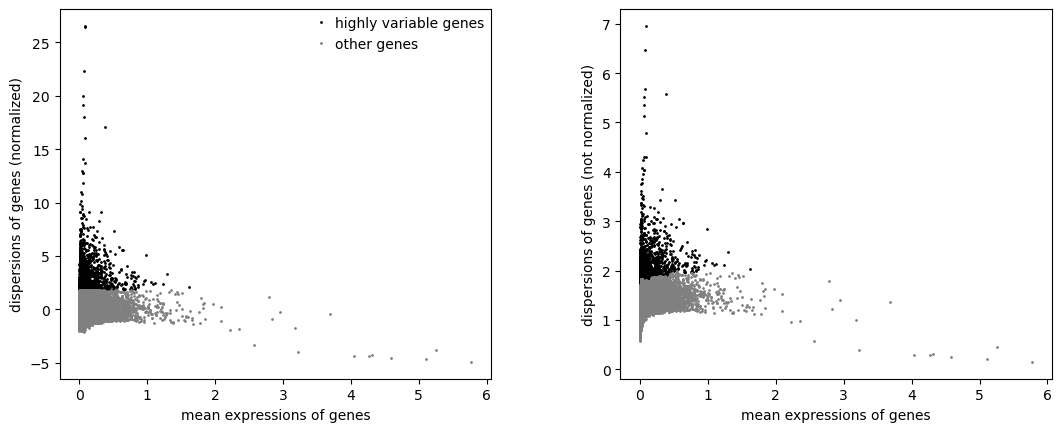


>>>Subsetting to top 2000 HVGs...

>>>Integrating with respect to Source Name (HARMONY)...
	***Using log1p layer for Harmony...


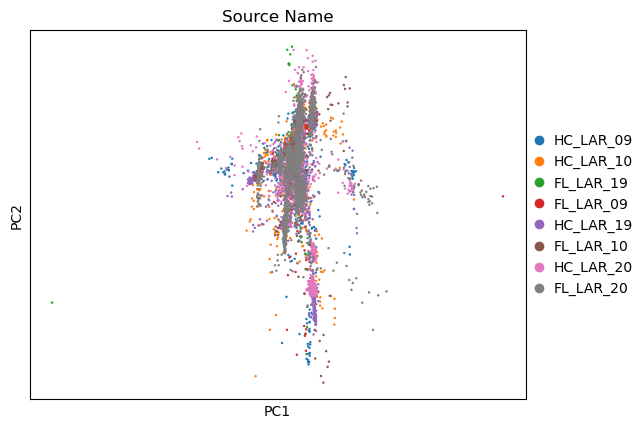

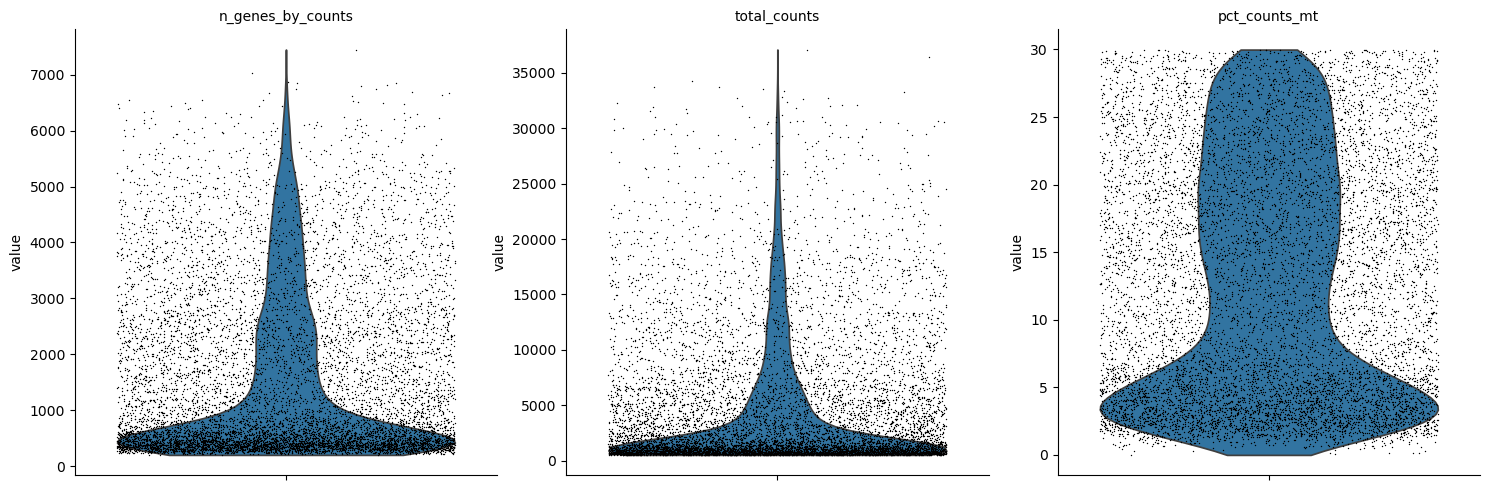

Cannot plot `n_cells_by_counts` because it is not in `adata.var`.


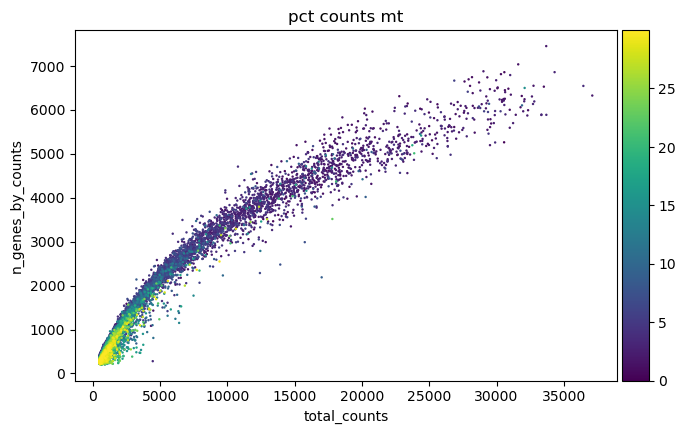

AnnData object with n_obs × n_vars = 9824 × 19952
    obs: 'Group', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 'Parameter Value[Feeding Schedule]', 'Parameter Value[duration]', 'Unit.1', 'Term Source REF.7', 'Term Accession Number.7', 'Parameter Value[light cycle]', 'Parameter Value[habitat]', 'Parameter Value[Enrichment material]', 'Protocol REF.1', 'Parameter Value[Euthanasia Location]', 'Parameter Value[Dissection

,Group,Source Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Genotype],Term Source REF.2,Term Accession Number.2,Characteristics[Sex],Term Source REF.3,Term Accession Number.3,Factor Value[Spaceflight],Term Source REF.4,Term Accession Number.4,Factor Value[Age],Unit,Term Source REF.5,Term Accession Number.5,Characteristics[Material Type],Term Source REF.6,Term Accession Number.6,Characteristics[Animal Source],Protocol REF,Parameter Value[Diet],Parameter Value[Feeding Schedule],Parameter Value[duration],Unit.1,Term Source REF.7,Term Accession Number.7,Parameter Value[light cycle],Parameter Value[habitat],Parameter Value[Enrichment material],Protocol REF.1,Parameter Value[Euthanasia Location],Parameter Value[Dissection Condition],Parameter Value[Euthanasia Method],Parameter Value[Sample Preservation Method],Term Source REF.8,Term Accession Number.8,Parameter Value[Time between landing to euthanasia],Unit.2,Term Source REF.9,Term Accession Number.9,Raw Data File,CellSort,Brain_Region,n_cells_original_Source Name,kws_pp_Source Name,n_genes_by_counts,total_counts,log1p_n_genes_by_counts,log1p_total_counts,total_counts_mt,pct_counts_mt,log1p_total_counts_mt,total_counts_ribo,pct_counts_ribo,log1p_total_counts_ribo,total_counts_hb,pct_counts_hb,log1p_total_counts_hb,n_counts,n_genes,doublet_score,predicted_doublet,kws_integrate
AAACCCAAGTATGATG-1_HC_LAR_09,Ground Control | 3 Weeks,HC_LAR_09,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,BALB/cAnNTac,OSD,https://osdr.nasa.gov/,Wild Type,NCIT,http://purl.obolibrary.org/obo/NCIT_C62195,Female,MESH,http://purl.bioontology.org/ontology/MESH/D005260,Ground Control,OSD,https://osdr.nasa.gov/,3,month,UO,http://purl.obolibrary.org/obo/UO_0000035,non-myeloid hippocampus,OSD,https://osdr.nasa.gov/,Taconic Biosciences,Animal Husbandry,Nutrient Upgraded Rodent Food Bar (NuRFB),ad libitum,40,day,UO,http://purl.obolibrary.org/obo/UO_0000033,12 h light/dark cycle,Rodent Flight Hardware (Transporter and Habitat),Hut,sample collection,On Earth,Upon euthanasia,"Bilateral thoracotomy with sedation, Cardiac p...",fresh specimen,OBI,http://purl.obolibrary.org/obo/OBI_0000971,2 - 4,day,UO,http://purl.obolibrary.org/obo/UO_0000033,GLDS-760_scRNA-Seq_SRX28491854_R1_raw.fastq.gz...,non-myeloid,hippocampus,1917,"{'min_max_genes': [218.0, None], 'min_max_cell...",5126,21994.0,8.542276,9.998570,405.0,1.841411,6.006353,1036.0,4.710375,6.944087,4.0,0.018187,1.609438,21994.0,5126,0.052632,False,"{'col_celltype': None, 'flavor': 'harmony', 'k..."
AAACCCATCGTCAACA-1_HC_LAR_09,Ground Control | 3 Weeks,HC_LAR_09,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,BALB/cAnNTac,OSD,https://osdr.nasa.gov/,Wild Type,NCIT,http://purl.obolibrary.org/obo/NCIT_C62195,Female,MESH,http://purl.bioontology.org/ontology/MESH/D005260,Ground Control,OSD,https://osdr.nasa.gov/,3,month,UO,http://purl.obolibrary.org/obo/UO_0000035,non-myeloid hippocampus,OSD,https://osdr.nasa.gov/,Taconic Biosciences,Animal Husbandry,Nutrient Upgraded Rodent Food Bar (NuRFB),ad libitum,40,day,UO,http://purl.obolibrary.org/obo/UO_0000033,12 h light/dark cycle,Rodent Flight Hardware (Transporter and Habitat),Hut,sample collection,On Earth,Upon euthanasia,"Bilateral thoracotomy with sedation, Cardiac p...",fresh specimen,OBI,http://purl.obolibrary.org/obo/OBI_0000971,2 - 4,day,UO,http://purl.obolibrary.org/obo/UO_0000033,GLDS-760_scRNA-Seq_SRX28491854_R1_raw.fastq.gz...,non-myeloid,hippocampus,1917,"{'min_max_genes': [218.0, None], 'min_max_cell...",371,685.0,5.918894,6.530878,203.0,29.635036,5.318120,6.0,0.875912,1.945910,0.0,0.000000,0.000000,685.0,371,0.033898,False,"{'col_celltype': None, 'flavor': 'harmony', 'k..."
AAACGAATCTAATTCC-1_HC_LAR_09,Ground Control | 3 Weeks,HC_LAR_09,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,BALB/cAnNTac,OSD,https://osdr.nasa.gov/,Wild Type,NCIT

In [11]:
%%time

# Integration Options
cct_available = kws_cluster is not None and (
    markers_predefined is not None)  # individual annotations available?
kws_vi = {"early_stopping": True,
          "batch_size": 1024,  # raise/lower if more/less than 16 GB VRAM
          "max_epochs": 100,
          "accelerator": "gpu",
          "categorical_covariate_keys": covariates_categorical,
          "continuous_covariate_keys": covariates_continuous,
          "n_latent": 40, "n_hidden": 400}  # scVI/scANVI arguments
# if covariates_categorical is not None:
#     print(metadata_combined[covariates_categorical + [
#         col_group]].value_counts().unstack(col_group).replace(
#             np.nan, 0).astype(int))

kws_integrate = {
    "col_celltype": cci_scanvi if cct_available else None,
    # "flavor": "scanvi",
    # "flavor": "scvi",
    # "flavor": "scanorama",
    "flavor": "harmony",
    "kws_pp": None, "kws_cluster": None,
    "vars_regress_out": vars_regress_out,
    "max_value": 10, "zero_center": True, "target_sum": 1e4,
    "n_top_genes": n_top_genes,
    "join": join_method, "merge": "same",
    "drop_non_hvgs": True,  # just for the integration part
    "use_rapids": True,
    "fill_value": np.nan if join_method == "outer" else None,
    "out_file": file_concat if ondisk is True else None
}
if kws_integrate["flavor"] != "harmony":
    kws_integrate.update(kws_vi)
    kws_integrate["col_batch"] = None  # suppress using batch as covariate
else:
    kws_integrate["col_sample"] = col_sample
    kws_integrate["col_subject"] = col_subject
    kws_integrate["col_batch"] = col_batch if len(batches) > 1 else None

# If scVI/scANVI Integration & Individual Annotations Available
if kws_integrate["flavor"] in ["scvi", "scanvi"] and cct_available is True:
    kws_integrate.update({"unlabeled_category": unlabeled_cat})

# Integrate & Store Integration Parameters in Object
self = scflow.Rna(files_individual if ondisk is True else adatas,
                  col_sample=col_sample, col_subject=col_subject,
                  col_batch=col_batch, kws_integrate=kws_integrate)
self.rna.obs = self.rna.obs.assign(kws_integrate=str(kws_integrate))

# Write Files for Processed/Integrated Objects?
if overwrite is True or not os.path.exists(file_new):
    self.rna.write_h5ad(file_new)
if ondisk is False:
    del adatas

# Display
print(self.rna)
self.rna.obs

# Clustering

Perform PCA, UMAP embedding, and Leiden clustering on the integrated object

Marker gene-related code looks at top markers by log2fold-change and adjusted p-value cutoffs and sorts by adjusted p-values. Plots for predefined marker expression by cluster (if available) and cluster DEGs are created. Use `kind = ["heat", "dot"]` to get dot plots too.

	***Building neighborhood with 50 neighbors...
	***Embedding UMAP with minimum distance 0.8...
	***Performing Leiden clustering with resolution 0.02...
        n_cells
leiden         
0          5500
3          1538
2          1534
1           753
5           327
4           172





leiden          0    1    2    3   4    5
Source Name                              
HC_LAR_09     602   71  543   92  15   24
HC_LAR_10     813   75   33   62  78   17
FL_LAR_19     129   13   81    9   9    2
FL_LAR_09     165   78   18   16   9    1
HC_LAR_19    1554   77  467  183  20  237
FL_LAR_10     448   69   21   70   1    2
HC_LAR_20     300   48  112  622  20   18
FL_LAR_20    1489  322  259  484  20   26





leiden                       0    1    2    3   4    5
Group                                                 
Ground Control | 3 Weeks  1415  146  576  154  93   41
Ground Control | 8 Weeks  1854  125  579  805  40  255
Space Flight | 3 Weeks     613  147   39   86  10    3
Space Flight | 

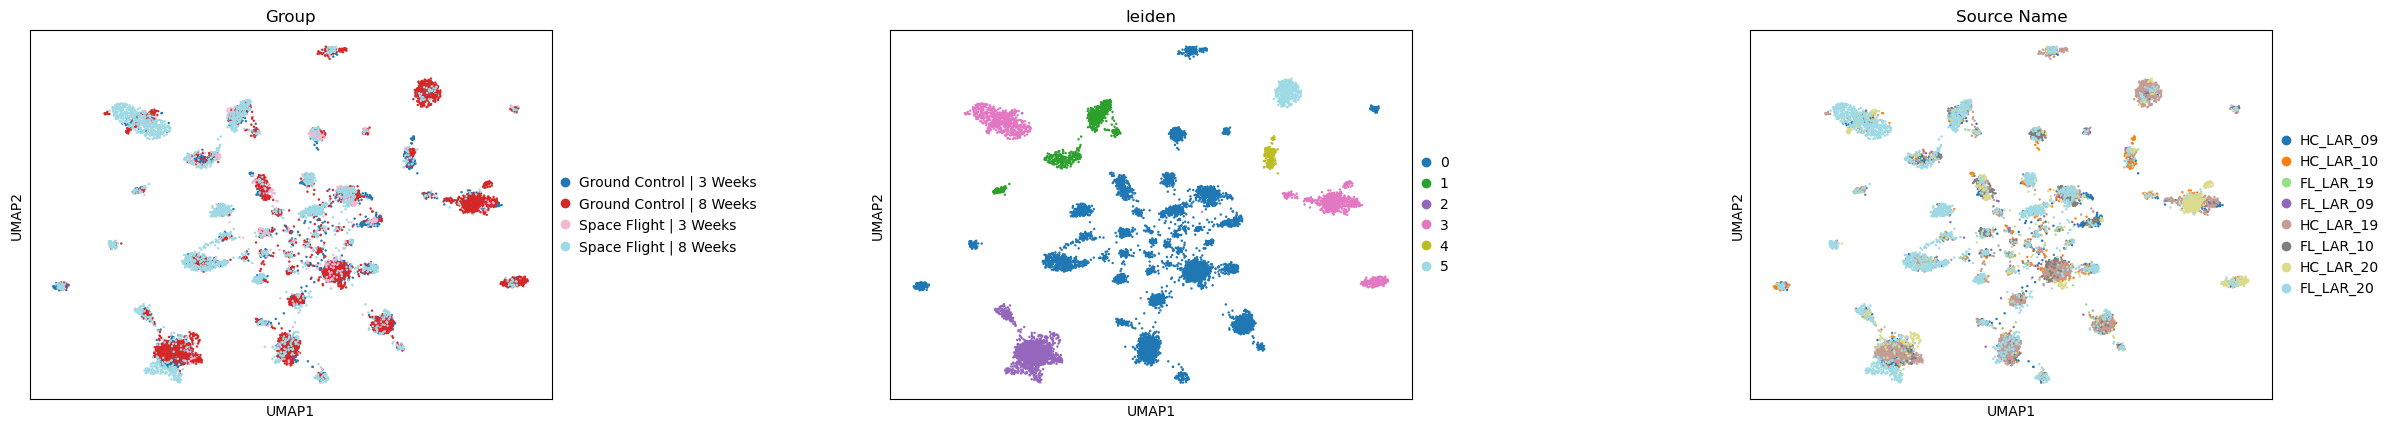

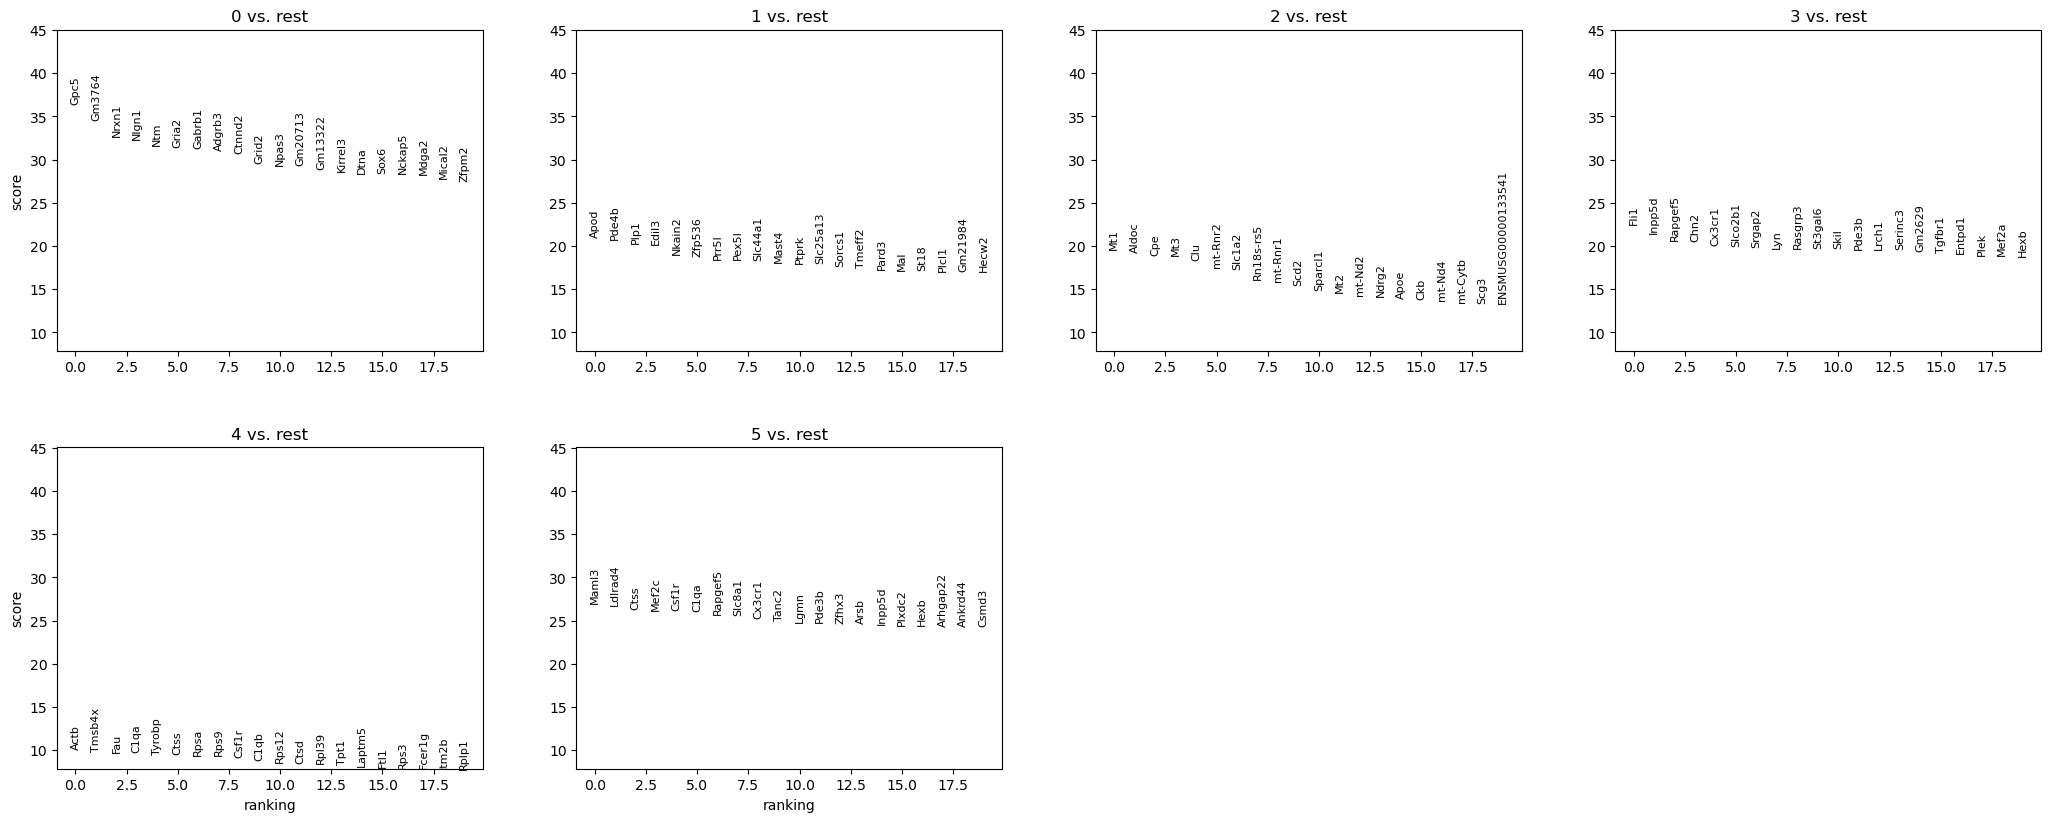

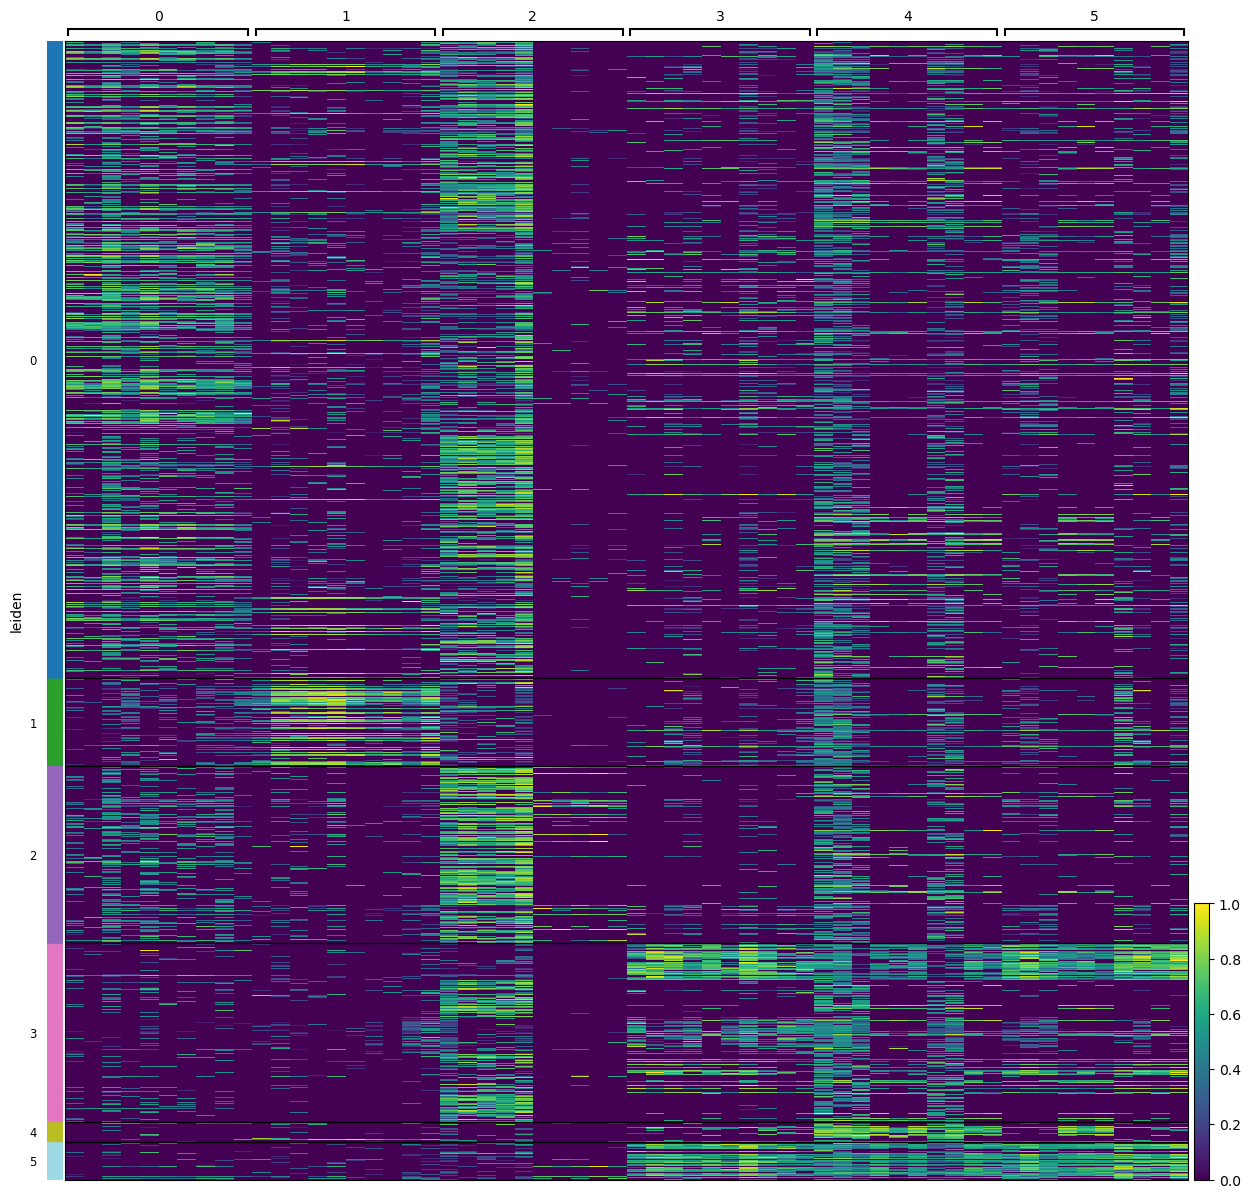

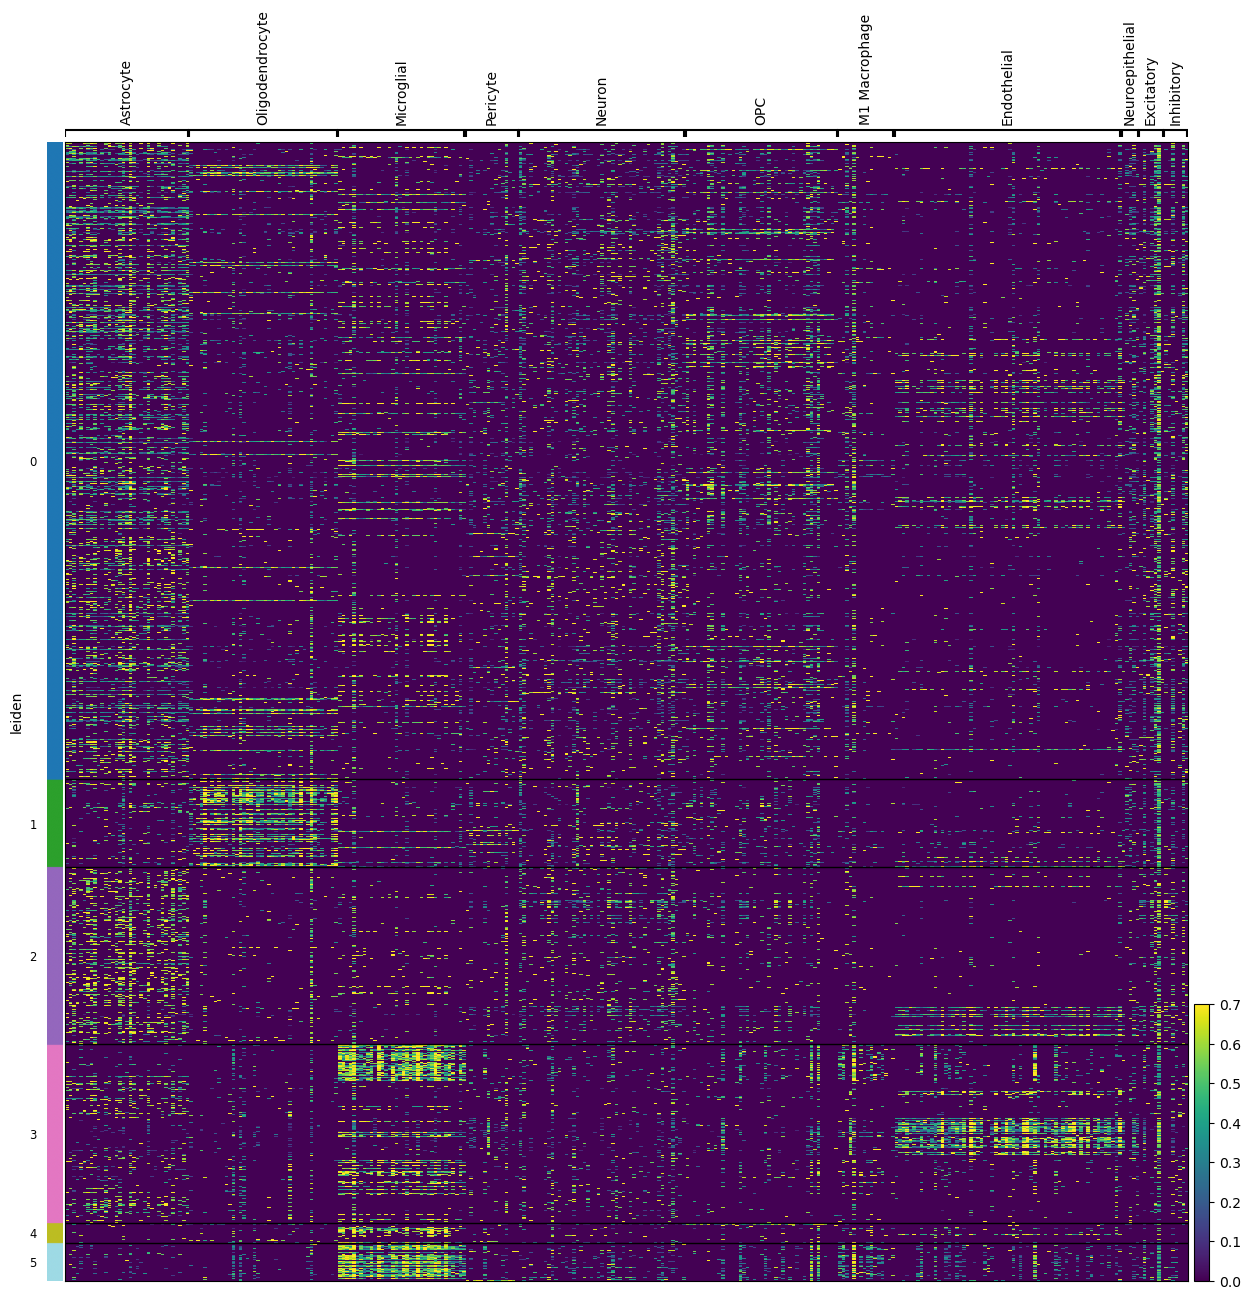

CPU times: user 2.77 s, sys: 282 ms, total: 3.05 s
Wall time: 2.53 s


scores  logfoldchanges          pvals      pvals_adj
leiden names                                                                      
3      Fli1                22.509893        2.467646   8.842080e-99   1.160639e-96
       Inpp5d              21.532278        2.791592   3.462594e-91   3.993392e-89
       Rapgef5             20.670805        2.335765   4.144982e-85   4.329878e-83
       Chn2                20.517662        2.059853   3.660246e-84   3.707068e-82
       Cx3cr1              20.068405        2.528381   8.557991e-81   8.016387e-79
       Slco2b1             20.012745        2.349342   2.197316e-80   2.020315e-78
       Srgap2              19.877964        1.999957   1.163958e-79   1.036754e-77
       Lyn                 19.773552        2.136254   8.550555e-79   7.482485e-77
       St3gal6             19.746349        2.041550   1.052208e-78   9.167531e-77
       Rasgrp3             19.746805        2.030459   1.096200e-78   9.509297e-77
0      Gpc5                36.459015        2.864309  3.881671e-270  7.744710e-266
       Gm3764              34.572399        3.074229  6.689971e-244  6.673916e-240
       Nrxn1               32.650208        2.078017  4.696169e-222  3.123265e-218
       Nlgn1               32.391003        2.224075  2.663784e-218  1.328695e-214
       Ntm                 31.629940        2.048989  6.468247e-209  2.581089e-205
       Gria2               31.427404        2.164839  2.436551e-206  8.102346e-203
       Gabrb1              31.362499        2.238567  3.592845e-205  1.024063e-201
       Adgrb3              31.048147        2.188224  1.531786e-201  3.820274e-198
       Ctnnd2              30.688953        1.936848  2.287731e-197  5.071646e-194
       Grid2               29.527172        2.172590  3.810268e-183  7.602247e-180
2      Mt1                 19.636057        1.614960   9.966456e-79   1.274684e-76
       Aldoc               19.225962        1.657032   9.828091e-76   1.136563e-73
       Mt3                 18.898666        1.607973   1.864699e-73   1.958131e-71
       Clu                 18.394627        1.589070   5.772572e-70   5.510735e-68
       Slc1a2              17.345327        1.632424   4.249776e-63   3.028269e-61
       Cpa6                12.980773        4.176697   1.138482e-36   2.811262e-35
       ENSMUSG00000137925  12.308068        3.612784   2.598082e-33   5.405312e-32
       Myo16               11.523447        2.321197   1.353855e-29   2.350923e-28
       ENSMUSG00000128216  11.391464        3.596380   6.004155e-29   1.002468e-27
       Ano3                11.365181        2.387097   7.130656e-29   1.184603e-27
5      Maml3               26.954517        3.887582   1.171143e-86   1.997149e-84
       Ldlrad4             26.721083        4.108230   1.635953e-85   2.570121e-83
       Mef2c               26.245903        3.380448   1.690484e-84   2.555192e-82
       Ctss                26.268349        4.347811   4.295736e-84   6.302097e-82
       Csf1r               26.165434        4.226557   2.190629e-83   3.167205e-81
       C1qa                26.058302        4.321156   3.795256e-83   5.447694e-81
       Slc8a1              25.577698        3.702958   8.464575e-82   1.197767e-79
       Rapgef5             25.686037        4.008231   1.281057e-81   1.787388e-79
       Cx3cr1              25.225885        4.460900   1.246820e-79   1.604940e-77
       Tanc2               25.076490        3.767627   2.124815e-79   2.683184e-77
1      Apod                20.975077        4.262029   1.301031e-77   1.236103e-74
       Pde4b               20.728603        3.351576   1.611148e-76   1.461165e-73
       Plp1                20.348736        4.110735   4.035606e-74   3.096862e-71
       Edil3               20.196232        3.795022   3.098374e-73   2.289583e-70
       Nkain2              19.099140        3.405721   4.056875e-67   1.882390e-64
       Zfp536              18.780846        3.530935   3.647418e-65   1.572047e-62
       Prr5l               18.501156        3.

In [54]:
%%time

# Clustering Options
resolution, min_dist = 0.02, 0.8
n_neighbors = 50
cct = "leiden"  # key added/column name

# Set Default Cell Type Column
col_celltype = cct
self._info["col_celltype"] = col_celltype

# Clustering
self.cluster(col_celltype=cct, resolution=resolution, min_dist=min_dist,
             kws_pca=False, layer="scaled", use_highly_variable=True,
             kws_neighbors=dict(n_neighbors=n_neighbors))  # cluster
self.rna.obs = self.rna.obs.assign(**{
       f"{cct}_resolution": resolution}).assign(
              **{f"{cct}_n_neighbors": n_neighbors}).assign(
                     **{f"{cct}_min_dist": min_dist})  # store parameters
_ = self.plot(kind="umap", wspace=0.5, palette="tab20",
              color=[col_batch, "leiden", col_sample])  # plot UMAP
print(self.rna.obs["leiden"].value_counts().to_frame("n_cells"))  # N/cluster
print("\n\n\n\n")
print(self.rna.obs.groupby(col_sample).apply(lambda x: x[
       cct].value_counts(), include_groups=False).unstack(1))  # by group
if col_subject is not None:
    print("\n\n\n\n")
    print(self.rna.obs.groupby(col_subject).apply(lambda x: x[
        cct].value_counts(), include_groups=False).unstack(1))  # by group
if col_batch is not None:
    print("\n\n\n\n")
    print(self.rna.obs.groupby(col_batch).apply(lambda x: x[
        cct].value_counts(), include_groups=False).unstack(1))  # by group

# DEGs (One Cluster versus All)
self.find_markers(col_celltype=cct)  # DEGs by cluster
markers_df = self.get_markers_df(
    n_genes=10, col_celltype=cct,
    p_threshold=1e-10, log2fc_threshold=1.5, log2fc_threshold_abs=False)
markers_dict = dict(markers_df.groupby(cct).apply(
    lambda x: list(x.reset_index().names)))  # dictionary version of df
_ = self.plot(genes=markers_dict, figsize=(15, 15),
              layer="scaled", standard_scale="var", kind="heat")
if markers_predefined is not None:
#     mks_c = dict(zip(markers_predefined, [markers_predefined[x].intersection(
#            self.rna.var_names) for x in markers_predefined]))
    mks_c = dict(zip(mks_collapsed, [mks_collapsed[x].intersection(
           self.rna.var_names) for x in mks_collapsed]))
#     mks_c["Inhibitory"] = mks_c["Inhibitory"].difference(
#            mks_c["Excitatory"])
#     mks_c["Excitatory"] = mks_c["Excitatory"].difference(
#            mks_c["Inhibitory"])
    _ = self.plot(genes=mks_c, figsize=(15, 15), vmax=0.7,
                  layer="scaled", standard_scale="var", kind="heat")
markers_df

# Annotate

Annotate cell types with various methods

## Annotate by Marker Gene Overlap

File from https://github.com/nasa/GeneLab_Data_Processing/blob/master/scRNAseq/10X_Chromium_3prime_Data/GeneLab_CellType_GeneMarkers/GL-DPPD-7111_GeneMarker_Files/GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv

**Example of the Expected Marker Definition Format**
```
markers_predefined = {
    "CD4 T cells": {"IL7R"},
    "CD14+ Monocytes": {"CD14", "LYZ"},
    "B cells": {"MS4A1"},
    "CD8 T cells": {"CD8A"},
    "NK cells": {"GNLY", "NKG7"},
    "FCGR3A+ Monocytes": {"FCGR3A", "MS4A7"},
    "Dendritic Cells": {"FCER1A", "CST3"},
    "Megakaryocytes": {"PPBP"},
}
```

annotation_by_overlap
OPC                55.99
Microglial         20.73
Astrocyte          15.61
Oligodendrocyte     7.66
Name: proportion, dtype: float64


leiden  annotation_by_overlap
4       Microglial                1.75
5       Microglial                3.33
1       Oligodendrocyte           7.66
2       Astrocyte                15.61
3       Microglial               15.66
0       OPC                      55.99
Name: proportion, dtype: float64

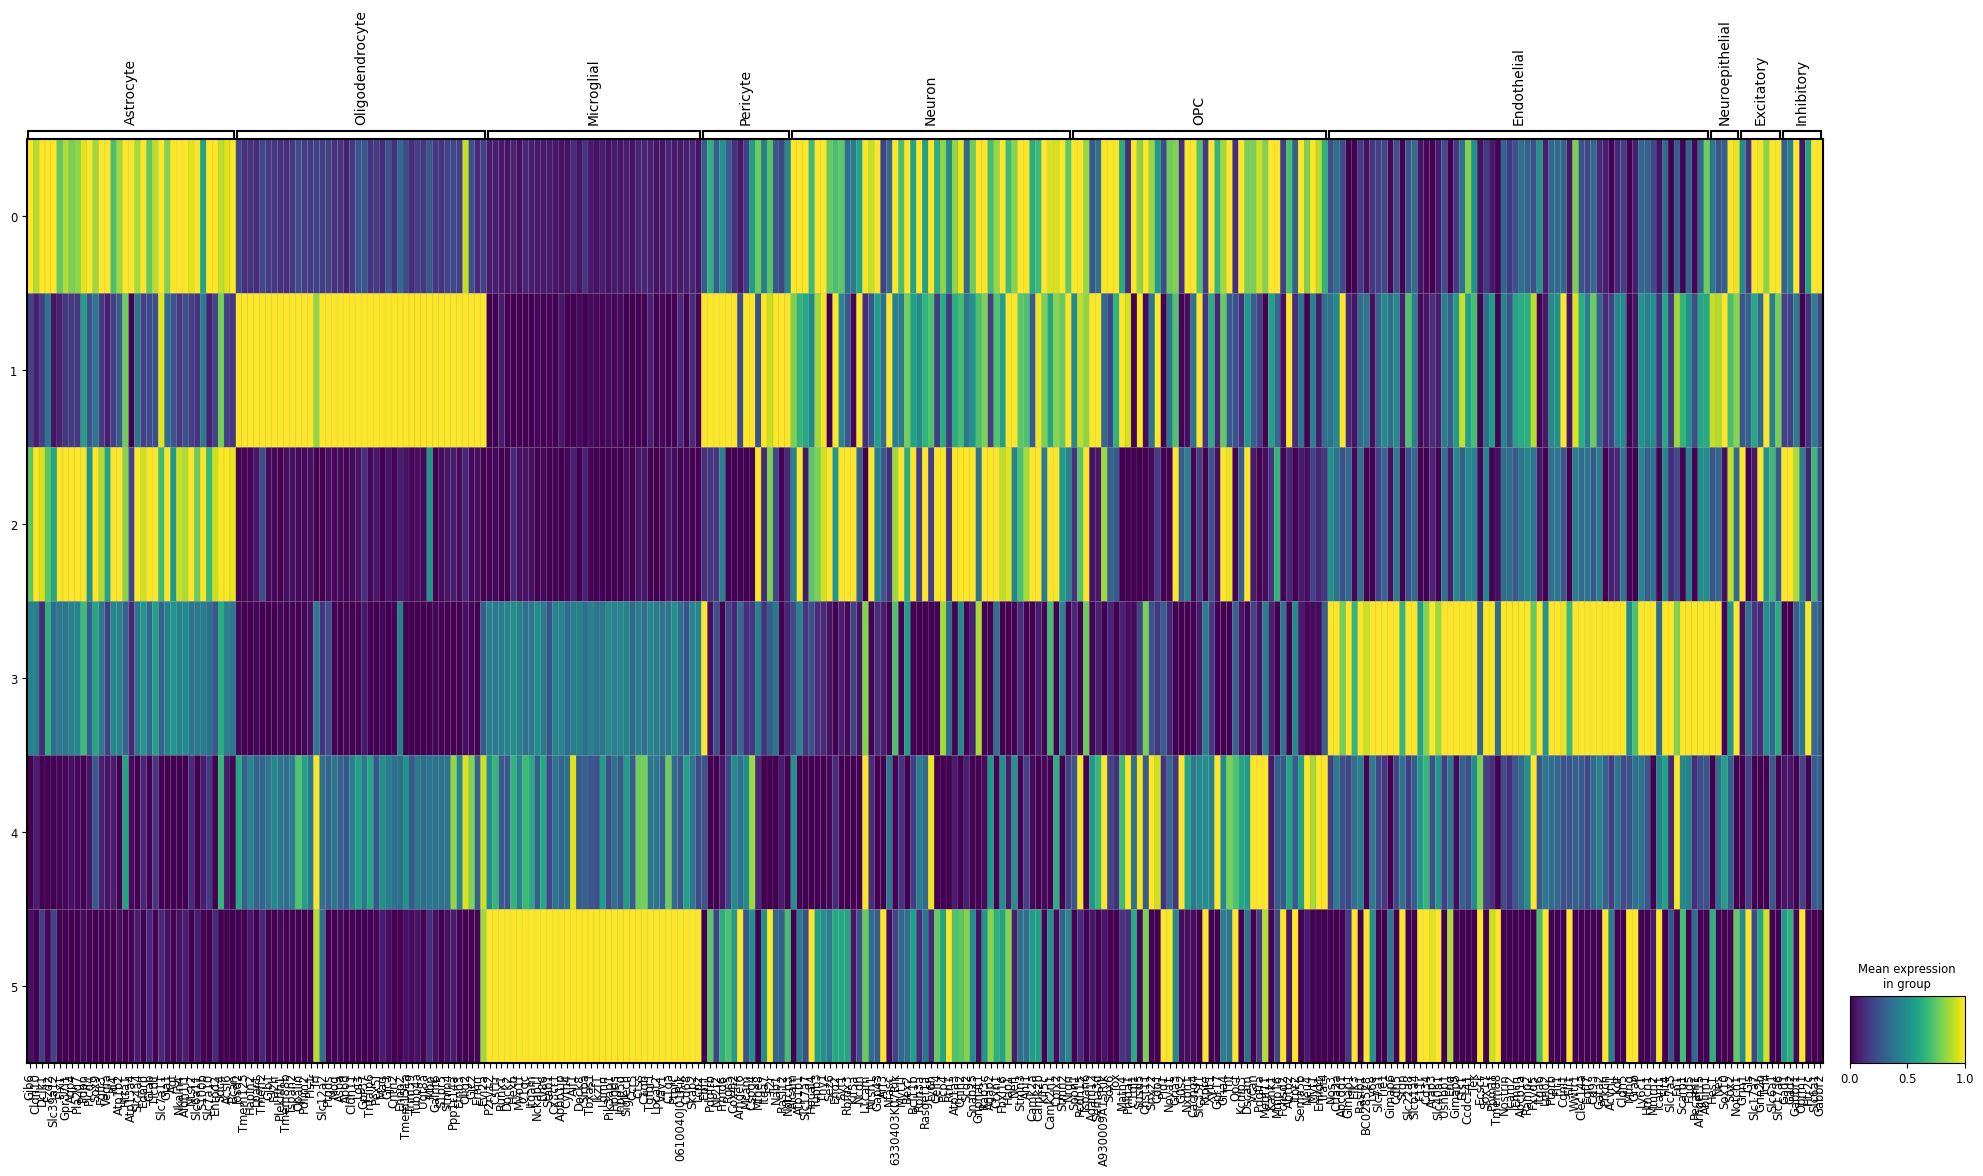

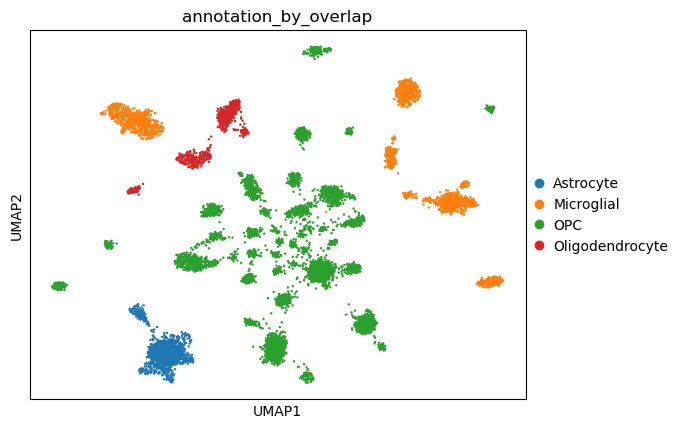

In [55]:
# Plot
mksn = {z: [g for g in mks_collapsed[z] if g in self.rna.var_names]
        for z in mks_collapsed if (z not in unannot_cts)} if isinstance(
            unannot_cts, list) else {z: [g for g in mks_collapsed[z] if (
                g in self.rna.var_names)] for z in mks_collapsed}
_ = self.plot(genes=mksn, figsize=(25, 12),
              layer="log1p", standard_scale="var", kind="matrix")

# Annotate
marker_matches = self.annotate(
    mksn,
    # celltypes_superhierarchical=celltypes_superhierarchical,
    col_celltype=col_celltype, col_celltype_new="annotation_by_overlap",
    top_n_markers=50,  # can only have this one or `adj_pval_threshold`
    # adj_pval_threshold=1e-10,
    # method="overlap_count",
    method="overlap_coef",
    # method="jaccard",
    overwrite=True)

# Plot Predefined Marker Expression
# cct = col_celltype
# # cct = "annotation_by_markers_individual"
# mks_col = dict(zip(self.rna.obs[cct].cat.categories, [list(
#     mks_collapsed[x].intersection(self.rna.var_names)
#     ) for x in self.rna.obs[cct].cat.categories]))
# _ = self.plot(genes=mks_col, figsize=(15, 15), col_celltype=cct,
#               layer="scaled", standard_scale="obs", kind="heat")

# Rename Any Labels As Pre-Specified
if rename_marker_based_annotation is not None:
    self.rna.obs.loc[:, "annotation_by_overlap"] = self.rna.obs[
        "annotation_by_overlap"].replace(rename_marker_based_annotation)

# Print & Plot Results
self.plot(kind="umap", color="annotation_by_overlap", wspace=0.4)
print(round(self.rna.obs["annotation_by_overlap"].value_counts(
    normalize=True) * 100, 2))
round(self.rna.obs[[col_celltype, "annotation_by_overlap"]
                   ].value_counts(normalize=True)* 100, 2).sort_values()

## Annotate with ToppGene

In [57]:
# Options
min_genes = 2  # minimum markers that have to overlap between Leiden & atlas
remove_strings = ["----L1-6", # "---[|]M.*",
                  "facs-", "-nan-",
                  # "-i_Gaba_3-.*",
                  "Brain_organoid-organoid_Kanton_Nature-Organoid-..-",
                  # "Non-neuronal-Macroglial-((^|)(Oligo|Astro))+-",
                  # "-Glut_E.*IL7R",
                  "cells hierarchy compared to all cells using T-S.*",
                  ".*-organoid_Tanaka_cellReport-.+-",
                  "...BrainAtlas -.*", "-eN2.*", "...Sample groups.*",
                  "...Sample Type, Dataset.*",
                  "-Neuronal",
                  " // Primary Cells by Cluster",
                  ".World...Primary Cells by Cluster",
                  "Brain_organoid-organoid_Velasco_nature-6_",
                  "Fetal_brain-fetalBrain_Zhong_nature-....-",
                  "Somatosensory_Cortex_....-Neuronal-",
                  "Non-neuronal-Non-dividing-",
                  "...Sample groups..6 Anatomical region groups., with 5.*",
                  "Brain_organoid-organoid_Paulsen_bioRxiv-",
                  "-Glut_E_(THEMIS)", "[(]THEMIS[)]",  # "[|].*",
                  "- method, tissue, subtissue, age, lineage.*"]
drop_name_patterns = ["striatum", "globus", "Entopeduncular",
                      "Substantia_nigra-", "Thalamus-"]
toppgene_rename_by_pattern = dict(
    Inhibitory=["Inh(_|ib)", "GABA"], Excitatory=["Excit", "Glut"],
    # Inhibitory=["Inh(_|ib)"], Excitatory=["Excit"],
    # # Gabaergic=["GABA"], Glutamatergic=["Glut"],
    Astrocyte=["Astrocyte","Astroglia", "Macroglial-Astro"],
    Microglial=["Microglia", "Micro"],
    Endothelial=["Endothelial"],
    Oligodendrocyte=[r"^(?=.*oligo)(?!.*poly)(?!.*opc).*"],
    OPC=["Polydendrocyte", "OPC"])
drop_regions = [
    "Mid-temporal_gyrus_(MTG)", "primary_auditory_cortex_(A1C)",
    "Somatosensory_Cortex_(S1)", "Anterior_Cingulate_gyrus_(CgG)",
    "Primary_Motor_Cortex_(M1)",
    "Mid-temporal_gyrus_(MTG)|Mid-temporal_gyrus_(MTG)",
    "primary_auditory_cortex_(A1C)|primary_auditory_cortex_(A1C)",
    "Somatosensory_Cortex_(S1)|Somatosensory_Cortex_(S1)",
    "Anterior_Cingulate_gyrus_(CgG)|Anterior_Cingulate_gyrus_(CgG)",
    "Primary_Motor_Cortex_(M1)|Primary_Motor_Cortex_(M1)",
    r"Neuronal|World / ",
    "Primary_Visual_cortex_(V1C)|Primary_Visual_cortex_(V1C)",
    "mon",
    "BMP_responsible_cell|6m", "bearing_cell|6m", "bearing_cell|GW16", "11",
    "Non-neuronal-Non-dividing",
    "Frontal_cortex|Frontal_cortex",
    "Primary_Visual_cortex_(V1C)", "Substantia_nigra",
    "Thalamus", "Hippocampus", "Frontal_cortex"
]  # remove if name is just a region or top-level hierarchical/undesired type
drop_regions = drop_regions + [f"{i}-Non-neuronal" for i in drop_regions]

# Query ToppGene
results_toppgene = scflow.pp.annotate_by_toppgene(
    markers_dict, remove_strings=remove_strings,
    species=species, min_genes=min_genes, source_patterns=source_patterns)

# Remove or Alter Certain Name Patterns
drop_names = results_toppgene.Name.apply(lambda x: not any((
    i.lower() in x.lower() for i in drop_name_patterns)))
results_toppgene = results_toppgene[drop_names]
rn_tg = results_toppgene.Name.apply(lambda x: {x: " | ".join([
    j for j in toppgene_rename_by_pattern if any((re.search(i.lower(
        ), x.lower()) is not None for i in toppgene_rename_by_pattern[
            j]))])}).apply(lambda x: np.nan if x[list(x.keys())[
                0]] == "" else x).dropna().reset_index(drop=True).apply(
                    lambda x: pd.Series(x)).stack().reset_index(
                        0, drop=True)  # renaming guide
results_toppgene = results_toppgene.replace({"Name": dict(rn_tg)})
results_toppgene = results_toppgene[~results_toppgene.Name.isin(drop_regions)]

# Map Labels (Plurality Vote If Sufficient or Top)
top_cs = dict(results_toppgene.groupby(
    "Gene Set").apply(lambda x: x.Name.iloc[:10].value_counts().index.values[
        0] if x.Name.iloc[:10].value_counts(
            normalize=True).iloc[0] >= 0.25 else x.Name[0]))
print("\n".join([f"{k}: {top_cs[k]}" for k in top_cs]), "\n\n")
if "annotation_toppgene" in self.rna.obs:
    self.rna.obs = self.rna.obs.drop("annotation_toppgene", axis=1)
self.rna.obs = self.rna.obs.join(self.rna.obs[col_celltype].replace(
    top_cs).to_frame("annotation_toppgene")).loc[self.rna.obs.index]

# Display Results
if "annotation_by_overlap" in self.rna.obs:
    print(round(self.rna.obs[["annotation_toppgene", "annotation_by_overlap"]
                             ].value_counts(normalize=True).sort_index(
                                 ) * 100, 2), "\n\n")
print(round(self.rna.obs["annotation_toppgene"].value_counts(
    normalize=True) * 100, 2))
results_toppgene.reset_index("ID", drop=True).drop([
    "QValueBonferroni", "QValueFDRBY", "QValueFDRBH",
    "TotalGenes", "Genes"], axis=1)

Server returned HTTP status code: 400
Content: {'error': 'No valid lookup found for symbol ENSMUSG00000137925'}
Server returned HTTP status code: 400
Content: {'error': 'No valid lookup found for symbol ENSMUSG00000128216'}
0: Excitatory
1: Oligodendrocyte
2: Astrocyte
3: Microglial | Endothelial
5: Microglial 


annotation_toppgene       annotation_by_overlap
Excitatory                OPC                      55.99
Oligodendrocyte           Oligodendrocyte           7.66
Astrocyte                 Astrocyte                15.61
Microglial | Endothelial  Microglial               15.66
4                         Microglial                1.75
Microglial                Microglial                3.33
Name: proportion, dtype: float64 


annotation_toppgene
Excitatory                  55.99
Microglial | Endothelial    15.66
Astrocyte                   15.61
Oligodendrocyte              7.66
Microglial                   3.33
4                            1.75
Name: proportion, dtype: float64


Name    PValue GenesInTerm GenesInQuery GenesInTermInQuery                                             Source  \
Gene Set Category                                                                                                                                                               
0        ToppCell  Brain_organoid-organoid_Velasco_nature-3_mon-C...       0.0         195            9                  5  Integration of Four Brain Organoid Datasets an...   
         ToppCell                                         Excitatory       0.0         197            9                  5           Comparison of human cortex and organoids   
         ToppCell                                         Excitatory       0.0         197            9                  5           Comparison of human cortex and organoids   
         ToppCell                                         Excitatory       0.0         197            9                  4           Comparison of human cortex and organoids   
         ToppCell  Neuronal-ventral_progenitors_and_neurons_1|Org...       0.0         197            9                  4  Integration of Four Brain Organoid Datasets an...   
         ToppCell  Neuronal-ventral_progenitors_and_neurons_1|Org...  0.000004         165            9                  3  Integration of Four Brain Organoid Datasets an...   
1        ToppCell                                    Oligodendrocyte       0.0         200           10                  7                              Human Adult Brain MTG   
         ToppCell                                    Oligodendrocyte       0.0         200           10                  7                              Human Adult Brain MTG   
         ToppCell                                    Oligodendrocyte       0.0         200           10                  7                              Human Adult Brain MTG   
         ToppCell                                    Oligodendrocyte       0.0         200           10                  7                              Human Adult Brain MTG   
         ToppCell                                    Oligodendrocyte       0.0         200           10                  7                              Human Adult Brain MTG   
         ToppCell                                    Oligodendrocyte       0.0         200           10                  7                              Human Adult Brain MTG   
         ToppCell                                    Oligodendrocyte       0.0         185           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         186           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         186           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         187           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         187           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         188           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         188           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         188           10                  5      Human Adult Multiple Cortical Areas SMART-seq   
         ToppCell                                    Oligodendrocyte       0.0         189           10                  5      Human Adult Multiple Cortical Areas SMART-

## Annotate with CellTypist

2026-03-19 21:24:20 | [INFO] 🔬 Input data has 9824 cells and 19952 genes
2026-03-19 21:24:20 | [INFO] 🔗 Matching reference genes in the model
2026-03-19 21:24:21 | [INFO] 🧬 4081 features used for prediction
2026-03-19 21:24:21 | [INFO] ⚖️ Scaling input data
2026-03-19 21:24:21 | [INFO] 🖋️ Predicting labels
2026-03-19 21:24:21 | [INFO] ✅ Prediction done!
2026-03-19 21:24:21 | [INFO] 👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
2026-03-19 21:24:21 | [INFO] ⛓️ Over-clustering input data with resolution set to 10
2026-03-19 21:24:22 | [INFO] 🗳️ Majority voting the predictions
2026-03-19 21:24:22 | [INFO] ✅ Majority voting done!


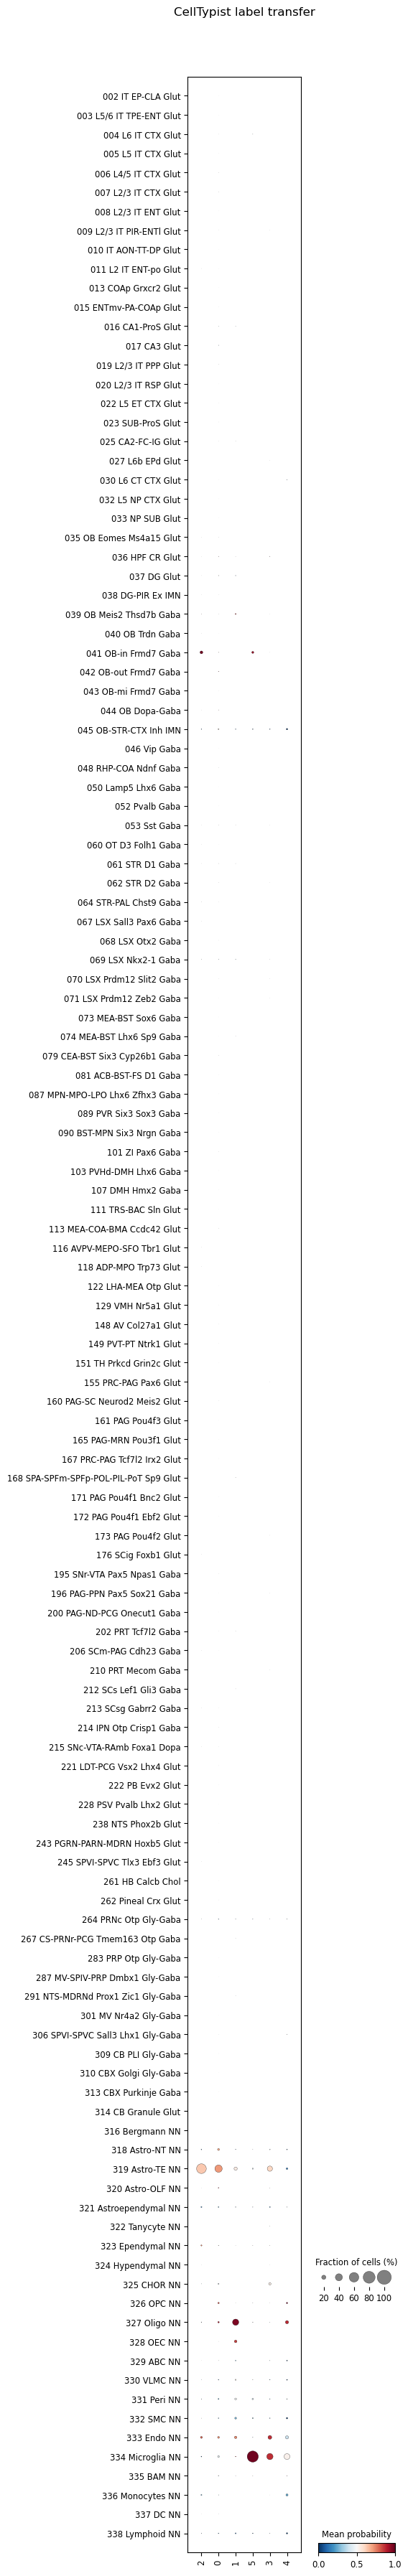

<timed exec>:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


CPU times: user 5.89 s, sys: 389 ms, total: 6.28 s
Wall time: 2.68 s


In [58]:
%%time

# To Aggregate More Specific Cell Types
celltypist_rename = dict(
    Gabaergic=["GABA"], Glutamatergic=["Glut"],
    Dopaminergic=["Dopa"], Serotonergic=["Sero"],
    Inhibitory=["Inh"], Excitatory=["Exc"],
    Astrocyte=["Astro"],
    Microglia=["Microglia"],
    Pericyte=["peri"],
    Monocyte=["Monocyte"],
    Lymphoid=["Lymphoid"],
    Endothelial=["Endothelial", "Endo"],
    Oligodendrocyte=[r"^(?=.*oligo)(?!.*poly)(?!.*opc).*"],
    OPC=["OPC", "Polydend"])

# Run CellTypist
self.rna.X = self.rna.layers["counts"].copy()
sc.pp.normalize_total(self.rna, target_sum=10000)
sc.pp.log1p(self.rna) # copy=True: do not update adata.X
predictions = self.annotate(
    model_celltypist, col_celltype=col_celltype, layer=None,
    col_celltype_new="", majority_voting=True, min_prop=0.5, use_GPU=True)
if "majority_voting" in self.rna.obs:
    self.rna.obs.loc[:, "majority_voting_short"] = self.rna.obs[
        "majority_voting"].apply(lambda x: " ".join(x.split(
            " ")[1:]) if all((i in [str(i) for i in np.arange(
                0, 10)] for i in x.split(" ")[
                    0])) else x)  # drop pointless #s in front of cell types

# Rename Cell Types
rn_ct = predictions.predicted_labels.groupby("majority_voting").apply(
    lambda x: {x.name: " | ".join([
        j for j in celltypist_rename if any((re.search(
            i.lower(), x.name.lower()) for i in celltypist_rename[
                j]))])}).apply(lambda x: {list(x.keys())[0]: list(x.keys(
                    ))[0]} if x[list(x.keys())[0] ] == "" else x).apply(
                        lambda x: pd.Series(x)).stack().reset_index(
                            0, drop=True)
if "annotation_majority_voting" in self.rna.obs:
    self.rna.obs = self.rna.obs.drop("annotation_majority_voting", axis=1)
self.rna.obs = self.rna.obs.join(self.rna.obs.replace({
    "majority_voting": dict(rn_ct)})["majority_voting"].to_frame(
        "annotation_majority_voting"))
self.rna.X = self.rna.layers["scaled"].copy()

## Annotate with Map My Cells

- Make sure to run the following bash commonds after activating the conda environment used for this notebook.

- Pull [`cell_type_mapper`](https://github.com/AllenInstitute/cell_type_mapper) from GitHub (clone into your home directory): `cd && git clone git@github.com:AllenInstitute/cell_type_mapper.git`

- Navigate to that directory and run `pip install .`

- Navigate to the folder containing this notebook.

- Install ABC Atlas (while in same directory as this notebook): `pip install -U git+https://github.com/alleninstitute/abc_atlas_access >& scratch/junk.txt`

- Pull lookup files (while in same directory as this notebook):
```
cd resources
wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WMB-10X/20240831/mouse_markers_230821.json
wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WMB-10X/20240831/precomputed_stats_ABC_revision_230821.h5
```

---

Note: To use GPU + Torch, you may need to alter the file "cell_type_mapper/src/cell_type_mapper/cell_by_gene/cell_by_gene.py" line `np.where(np.logical_not(np.isfinite(data)))[0]` to read instead

```
try:
    nan_rows = np.where(
        np.logical_not(np.isfinite(data.cpu().numpy())))[0]
except Exception:
    nan_rows = np.where(np.logical_not(np.isfinite(data)))[0]
```

You may have to run the following code in this notebook:

```
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
```

and

    `_correlation_dot_gpu()` in distance_utils.py change
    `correlation = torch.matmul(arr0, arr1)` to

```
try:
    correlation = torch.matmul(arr0, arr1)
except RuntimeError as err:
    if "CUBLAS_STATUS_NOT_INITIALIZED" in str(err):
        arr0_cpu = arr0.cpu()
        arr1_cpu = arr1.cpu()
        correlation = torch.matmul(arr0_cpu, arr1_cpu).to(arr0.device)
    else:
        raise
```

to manage processes/memory.

In [ ]:
# %%time

# # Write File to Use as Input for Map My Cells
# if overwrite is True or not os.path.exists(file_new):
#     os.makedirs("data", exist_ok=True)
#     self.rna.X = self.rna.layers["counts"]
#     self.rna.write_h5ad(file_new)
# else:
#     raise ValueError("Must be able to overwrite to run Map My Cells.")

# # Run Map My Cells
# self.rna = scflow.pp.run_mapbraincells(
#     file_new, map_my_cells_source=map_my_cells_source,
#     dir_scratch="scratch", dir_resources="resources",
#     validate_output_file="scratch/tmp.h5ad",  # map_to_ensembl=True,
#     map_my_cells_region_keys=map_my_cells_region_keys,
#     map_my_cells_cell_keys=map_my_cells_cell_keys, verbose_stdout=True,
#     n_processors=4, chunk_size=5000, max_gb=5)

# View Results
# _ = self.plot(kind="umap", color=["cellmap_class_name"])
# if "annotation_toppgene" in self.rna.obs:
#     print(self.rna.obs[["cellmap_class_name", "annotation_toppgene"]
#                        ].value_counts().sort_index())
# self.rna.obs[[i for i in self.rna.obs if "cellmap" in i and "ori" not in i]]

## Compare Annotations

annotation_by_overlap  annotation_majority_voting  annotation_toppgene     
Astrocyte              Astrocyte                   Astrocyte                   64.9
                       Heterogeneous               Astrocyte                   16.6
                       Gabaergic                   Astrocyte                   12.1
                       Endothelial                 Astrocyte                    3.7
                       Monocyte                    Astrocyte                    2.7
Microglial             Microglia                   Microglial | Endothelial    30.7
                       Astrocyte                   Microglial | Endothelial    20.4
                       Microglia                   Microglial                  16.1
                       325 CHOR NN                 Microglial | Endothelial    10.2
                       Endothelial                 Microglial | Endothelial     9.8
                       Heterogeneous               4                            7.8


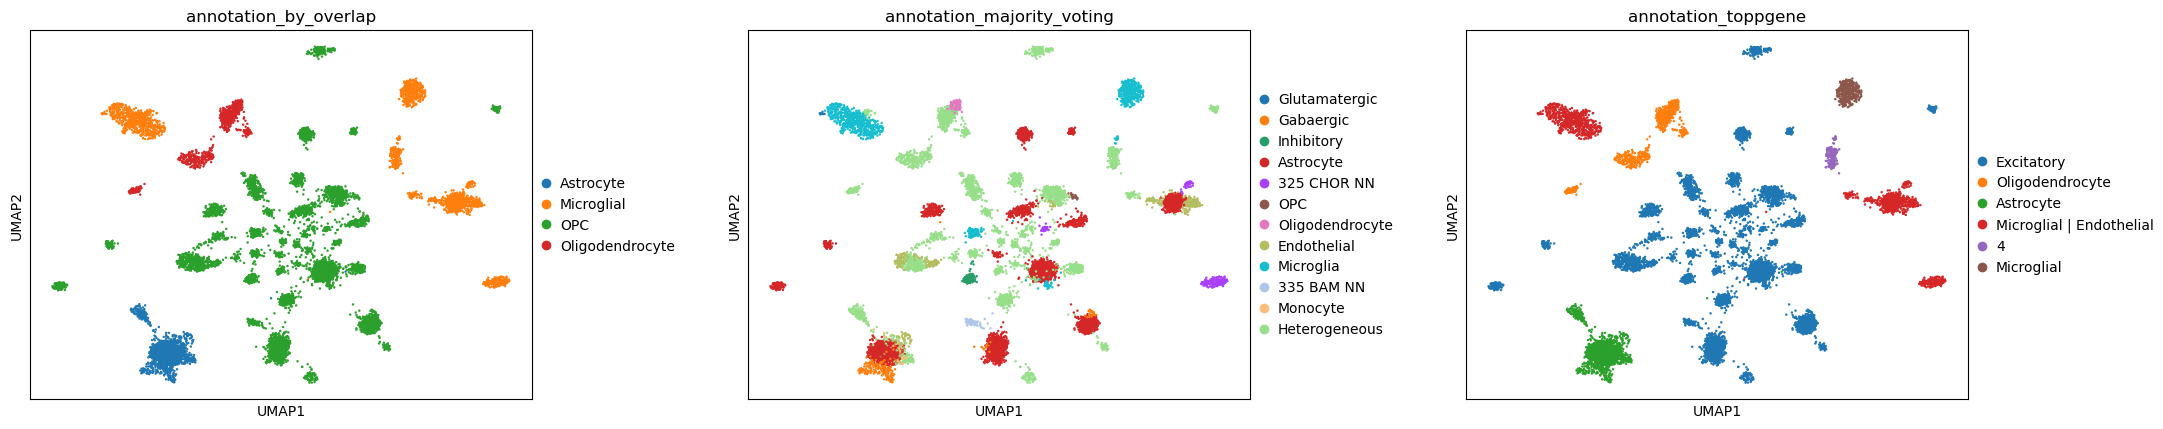

In [59]:
cols = ["annotation_by_overlap", "annotation_majority_voting",
        "annotation_scanvi", "annotation_toppgene"]
# cols += [i for i in [
#     "cellmap_class_name", "cellmap_subclass_name"] if i in self.rna.obs]
cols = [i for i in cols if i in self.rna.obs]

# Plot UMAPs
self.plot(kind="umap", color=cols, wspace=0.3)

# Compare
# self.rna.obs[cols].value_counts().reset_index().groupby(cols[0]).apply(
#         lambda x: x.sort_values("count", ascending=False).reset_index(
#                 drop=True), include_groups=False).reset_index(
#                         -1, drop=True).set_index(cols[1:], append=True)
self.rna.obs[cols].groupby(cols[0]).apply(
        lambda x: round(100 * x.value_counts(normalize=True), 1).sort_index(
                ).sort_values(ascending=False), include_groups=False)

# Final Write

In [ ]:
# Descriptives
if all((i in self.rna.obs for i in [
        "Factor Value[Age]", "Characteristics[Age at Euthanasia]"])):
    print(self.rna.obs[["Factor Value[Age]",
                        "Characteristics[Age at Euthanasia]"]].value_counts())

# Write h5ad
# self.rna.X = self.rna.layers["counts"].copy()
if overwrite is True or not os.path.exists(file_new):
    print("\n\n", f"Writing file to {file_new}...")
    self.rna.write_h5ad(file_new)

## Write Version Compatible with Older Packages
# adata = self.rna.copy()
# adata.uns = {}
# # adata.write_h5ad(os.path.splitext(file_new)[0] + "_compatible.h5ad")

# Send Email with Output When Done
if email is not None and html_out is not None:
    os.system(f"jupyter nbconvert --to html {cur_file}")
    os.system(f"echo 'yay' | mutt -s 'JOB DONE' -a {html_out} -- {email}")